# PyTorch Seq2Seq for Survey Analysis
Codebase cloned from https://github.com/bentrevett/pytorch-seq2seq and adapted for the survey of the *Neural Machine Translation by Jointly Learning to Align and Translate* paper.

NOTE: If you have the `tut3-model.pt` file and want to use it, Set below's `do_not_retrain=True` so it doesn't retrain.

**All code from here until `Flaw Search` is mostly unchanged from the adapted codebase except with additional imports and compatability/qol changes.**

All code in `Flaw Search` were implemented for the purpose of this survey with the new datasets.

In [1]:
do_not_retrain=True

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import spacy
import datasets
import torchtext
import tqdm
import evaluate
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# New libraries for stress testing and training on bigger dataset
import pandas as pd
from pyarrow import Table
from pyarrow import array as pa_array
from random import sample

In [3]:
seed = 1234

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [4]:
dataset = datasets.load_dataset("bentrevett/multi30k")
dataset

DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})

In [5]:
train_data, valid_data, test_data = (
    dataset["train"],
    dataset["validation"],
    dataset["test"],
)

In [6]:
en_nlp = spacy.load("en_core_web_sm")
de_nlp = spacy.load("de_core_news_sm")

In [7]:
def tokenize_example(example, en_nlp, de_nlp, max_length, lower, sos_token, eos_token):
    en_tokens = [token.text for token in en_nlp.tokenizer(example["en"])][:max_length]
    de_tokens = [token.text for token in de_nlp.tokenizer(example["de"])][:max_length]
    if lower:
        en_tokens = [token.lower() for token in en_tokens]
        de_tokens = [token.lower() for token in de_tokens]
    en_tokens = [sos_token] + en_tokens + [eos_token]
    de_tokens = [sos_token] + de_tokens + [eos_token]
    return {"en_tokens": en_tokens, "de_tokens": de_tokens}

In [8]:
max_length = 1_000
lower = True
sos_token = "<sos>"
eos_token = "<eos>"

fn_kwargs = {
    "en_nlp": en_nlp,
    "de_nlp": de_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}

train_data = train_data.map(tokenize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(tokenize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(tokenize_example, fn_kwargs=fn_kwargs)

In [9]:
# Changed from original: With tortext >0.9, torchtext.vocab.build_vocab_from_iterator must be imported instead of called directly
from torchtext.vocab import build_vocab_from_iterator

/home/pikasan/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/home/pikasan/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [10]:
min_freq = 2
unk_token = "<unk>"
pad_token = "<pad>"

special_tokens = [
    unk_token,
    pad_token,
    sos_token,
    eos_token,
]

en_vocab = build_vocab_from_iterator(
    train_data["en_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

de_vocab = build_vocab_from_iterator(
    train_data["de_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

In [11]:
assert en_vocab[unk_token] == de_vocab[unk_token]
assert en_vocab[pad_token] == de_vocab[pad_token]

unk_index = en_vocab[unk_token]
pad_index = en_vocab[pad_token]

In [12]:
en_vocab.set_default_index(unk_index)
de_vocab.set_default_index(unk_index)

In [13]:
def numericalize_example(example, en_vocab, de_vocab):
    en_ids = en_vocab.lookup_indices(example["en_tokens"])
    de_ids = de_vocab.lookup_indices(example["de_tokens"])
    return {"en_ids": en_ids, "de_ids": de_ids}

In [14]:
fn_kwargs = {"en_vocab": en_vocab, "de_vocab": de_vocab}

train_data = train_data.map(numericalize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(numericalize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(numericalize_example, fn_kwargs=fn_kwargs)

In [15]:
data_type = "torch"
format_columns = ["en_ids", "de_ids"]

train_data = train_data.with_format(
    type=data_type, columns=format_columns, output_all_columns=True
)

valid_data = valid_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

test_data = test_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [16]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_en_ids = [example["en_ids"] for example in batch]
        batch_de_ids = [example["de_ids"] for example in batch]
        batch_en_ids = nn.utils.rnn.pad_sequence(batch_en_ids, padding_value=pad_index)
        batch_de_ids = nn.utils.rnn.pad_sequence(batch_de_ids, padding_value=pad_index)
        batch = {
            "en_ids": batch_en_ids,
            "de_ids": batch_de_ids,
        }
        return batch

    return collate_fn

In [17]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )
    return data_loader

In [18]:
batch_size = 128

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

In [19]:
class Encoder(nn.Module):
    def __init__(
        self, input_dim, embedding_dim, encoder_hidden_dim, decoder_hidden_dim, dropout
    ):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.rnn = nn.GRU(embedding_dim, encoder_hidden_dim, bidirectional=True)
        self.fc = nn.Linear(encoder_hidden_dim * 2, decoder_hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src length, batch size]
        embedded = self.dropout(self.embedding(src))
        # embedded = [src length, batch size, embedding dim]
        outputs, hidden = self.rnn(embedded)
        # outputs = [src length, batch size, hidden dim * n directions]
        # hidden = [n layers * n directions, batch size, hidden dim]
        # hidden is stacked [forward_1, backward_1, forward_2, backward_2, ...]
        # outputs are always from the last layer
        # hidden [-2, :, : ] is the last of the forwards RNN
        # hidden [-1, :, : ] is the last of the backwards RNN
        # initial decoder hidden is final hidden state of the forwards and backwards
        # encoder RNNs fed through a linear layer
        hidden = torch.tanh(
            self.fc(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1))
        )
        # outputs = [src length, batch size, encoder hidden dim * 2]
        # hidden = [batch size, decoder hidden dim]
        return outputs, hidden

In [20]:
class Attention(nn.Module):
    def __init__(self, encoder_hidden_dim, decoder_hidden_dim):
        super().__init__()
        self.attn_fc = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim, decoder_hidden_dim
        )
        self.v_fc = nn.Linear(decoder_hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden = [batch size, decoder hidden dim]
        # encoder_outputs = [src length, batch size, encoder hidden dim * 2]
        batch_size = encoder_outputs.shape[1]
        src_length = encoder_outputs.shape[0]
        # repeat decoder hidden state src_length times
        hidden = hidden.unsqueeze(1).repeat(1, src_length, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # hidden = [batch size, src length, decoder hidden dim]
        # encoder_outputs = [batch size, src length, encoder hidden dim * 2]
        energy = torch.tanh(self.attn_fc(torch.cat((hidden, encoder_outputs), dim=2)))
        # energy = [batch size, src length, decoder hidden dim]
        attention = self.v_fc(energy).squeeze(2)
        # attention = [batch size, src length]
        return torch.softmax(attention, dim=1)

In [21]:
class Decoder(nn.Module):
    def __init__(
        self,
        output_dim,
        embedding_dim,
        encoder_hidden_dim,
        decoder_hidden_dim,
        dropout,
        attention,
    ):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, embedding_dim)
        self.rnn = nn.GRU((encoder_hidden_dim * 2) + embedding_dim, decoder_hidden_dim)
        self.fc_out = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim + embedding_dim, output_dim
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input = [batch size]
        # hidden = [batch size, decoder hidden dim]
        # encoder_outputs = [src length, batch size, encoder hidden dim * 2]
        input = input.unsqueeze(0)
        # input = [1, batch size]
        embedded = self.dropout(self.embedding(input))
        # embedded = [1, batch size, embedding dim]
        a = self.attention(hidden, encoder_outputs)
        # a = [batch size, src length]
        a = a.unsqueeze(1)
        # a = [batch size, 1, src length]
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # encoder_outputs = [batch size, src length, encoder hidden dim * 2]
        weighted = torch.bmm(a, encoder_outputs)
        # weighted = [batch size, 1, encoder hidden dim * 2]
        weighted = weighted.permute(1, 0, 2)
        # weighted = [1, batch size, encoder hidden dim * 2]
        rnn_input = torch.cat((embedded, weighted), dim=2)
        # rnn_input = [1, batch size, (encoder hidden dim * 2) + embedding dim]
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        # output = [seq length, batch size, decoder hid dim * n directions]
        # hidden = [n layers * n directions, batch size, decoder hid dim]
        # seq len, n layers and n directions will always be 1 in this decoder, therefore:
        # output = [1, batch size, decoder hidden dim]
        # hidden = [1, batch size, decoder hidden dim]
        # this also means that output == hidden
        assert (output == hidden).all()
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        # prediction = [batch size, output dim]
        return prediction, hidden.squeeze(0), a.squeeze(1)

In [22]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio):
        # src = [src length, batch size]
        # trg = [trg length, batch size]
        # teacher_forcing_ratio is probability to use teacher forcing
        # e.g. if teacher_forcing_ratio is 0.75 we use teacher forcing 75% of the time
        batch_size = src.shape[1]
        trg_length = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        # tensor to store decoder outputs
        outputs = torch.zeros(trg_length, batch_size, trg_vocab_size).to(self.device)
        # encoder_outputs is all hidden states of the input sequence, back and forwards
        # hidden is the final forward and backward hidden states, passed through a linear layer
        encoder_outputs, hidden = self.encoder(src)
        # outputs = [src length, batch size, encoder hidden dim * 2]
        # hidden = [batch size, decoder hidden dim]
        # first input to the decoder is the <sos> tokens
        input = trg[0, :]
        for t in range(1, trg_length):
            # insert input token embedding, previous hidden state and all encoder hidden states
            # receive output tensor (predictions) and new hidden state
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            # output = [batch size, output dim]
            # hidden = [n layers, batch size, decoder hidden dim]
            # place predictions in a tensor holding predictions for each token
            outputs[t] = output
            # decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio
            # get the highest predicted token from our predictions
            top1 = output.argmax(1)
            # if teacher forcing, use actual next token as next input
            # if not, use predicted token
            input = trg[t] if teacher_force else top1
            # input = [batch size]
        return outputs

In [23]:
input_dim = len(de_vocab)
output_dim = len(en_vocab)
encoder_embedding_dim = 256
decoder_embedding_dim = 256
encoder_hidden_dim = 512
decoder_hidden_dim = 512
encoder_dropout = 0.5
decoder_dropout = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

attention = Attention(encoder_hidden_dim, decoder_hidden_dim)

encoder = Encoder(
    input_dim,
    encoder_embedding_dim,
    encoder_hidden_dim,
    decoder_hidden_dim,
    encoder_dropout,
)

decoder = Decoder(
    output_dim,
    decoder_embedding_dim,
    encoder_hidden_dim,
    decoder_hidden_dim,
    decoder_dropout,
    attention,
)

model = Seq2Seq(encoder, decoder, device).to(device)

In [24]:
def init_weights(m):
    for name, param in m.named_parameters():
        if "weight" in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)


model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7853, 256)
    (rnn): GRU(256, 512, bidirectional=True)
    (fc): Linear(in_features=1024, out_features=512, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn_fc): Linear(in_features=1536, out_features=512, bias=True)
      (v_fc): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(5893, 256)
    (rnn): GRU(1280, 512)
    (fc_out): Linear(in_features=1792, out_features=5893, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [25]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 20,518,405 trainable parameters


In [26]:
optimizer = optim.Adam(model.parameters())

In [27]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_index)

In [28]:
def train_fn(
    model, data_loader, optimizer, criterion, clip, teacher_forcing_ratio, device
):
    model.train()
    epoch_loss = 0
    for i, batch in enumerate(data_loader):
        src = batch["de_ids"].to(device)
        trg = batch["en_ids"].to(device)
        # src = [src length, batch size]
        # trg = [trg length, batch size]
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)
        # output = [trg length, batch size, trg vocab size]
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        # output = [(trg length - 1) * batch size, trg vocab size]
        trg = trg[1:].view(-1)
        # trg = [(trg length - 1) * batch size]
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

In [29]:
def evaluate_fn(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            src = batch["de_ids"].to(device)
            trg = batch["en_ids"].to(device)
            # src = [src length, batch size]
            # trg = [trg length, batch size]
            output = model(src, trg, 0)  # turn off teacher forcing
            # output = [trg length, batch size, trg vocab size]
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            # output = [(trg length - 1) * batch size, trg vocab size]
            trg = trg[1:].view(-1)
            # trg = [(trg length - 1) * batch size]
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

In [30]:
if not do_not_retrain:
    n_epochs = 10
    clip = 1.0
    teacher_forcing_ratio = 0.5
    
    best_valid_loss = float("inf")
    
    for epoch in tqdm.tqdm(range(n_epochs)):
        train_loss = train_fn(
            model,
            train_data_loader,
            optimizer,
            criterion,
            clip,
            teacher_forcing_ratio,
            device,
        )
        valid_loss = evaluate_fn(
            model,
            valid_data_loader,
            criterion,
            device,
        )
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), "tut3-model.pt")
        print(f"\tTrain Loss: {train_loss:7.3f} | Train PPL: {np.exp(train_loss):7.3f}")
        print(f"\tValid Loss: {valid_loss:7.3f} | Valid PPL: {np.exp(valid_loss):7.3f}")

In [31]:
model.load_state_dict(torch.load("tut3-model.pt"))

test_loss = evaluate_fn(model, test_data_loader, criterion, device)

print(f"| Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f} |")

| Test Loss: 3.305 | Test PPL:  27.242 |


In [32]:
def translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
    max_output_length=25,
):
    model.eval()
    with torch.no_grad():
        if isinstance(sentence, str):
            de_tokens = [token.text for token in de_nlp.tokenizer(sentence)]
        else:
            de_tokens = [token for token in sentence]
        if lower:
            de_tokens = [token.lower() for token in de_tokens]
        de_tokens = [sos_token] + de_tokens + [eos_token]
        ids = de_vocab.lookup_indices(de_tokens)
        tensor = torch.LongTensor(ids).unsqueeze(-1).to(device)
        encoder_outputs, hidden = model.encoder(tensor)
        inputs = en_vocab.lookup_indices([sos_token])
        attentions = torch.zeros(max_output_length, 1, len(ids))
        for i in range(max_output_length):
            inputs_tensor = torch.LongTensor([inputs[-1]]).to(device)
            output, hidden, attention = model.decoder(
                inputs_tensor, hidden, encoder_outputs
            )
            attentions[i] = attention
            predicted_token = output.argmax(-1).item()
            inputs.append(predicted_token)
            if predicted_token == en_vocab[eos_token]:
                break
        en_tokens = en_vocab.lookup_tokens(inputs)
    return en_tokens, de_tokens, attentions[: len(en_tokens) - 1]

In [33]:
def plot_attention(sentence, translation, attention):
    fig, ax = plt.subplots(figsize=(10, 10))
    attention = attention.squeeze(1).numpy()
    cax = ax.matshow(attention, cmap="bone")
    ax.set_xticks(ticks=np.arange(len(sentence)), labels=sentence, rotation=90, size=15)
    translation = translation[1:]
    ax.set_yticks(ticks=np.arange(len(translation)), labels=translation, size=15)
    plt.show()
    plt.close()

In [34]:
sentence = test_data[0]["de"]
expected_translation = test_data[0]["en"]

sentence, expected_translation

('Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.',
 'A man in an orange hat starring at something.')

In [35]:
translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [36]:
translation

['<sos>',
 'a',
 'man',
 'in',
 'an',
 'orange',
 'hat',
 'is',
 'welding',
 'something',
 '.',
 '<eos>']

In [37]:
sentence_tokens

['<sos>',
 'ein',
 'mann',
 'mit',
 'einem',
 'orangefarbenen',
 'hut',
 ',',
 'der',
 'etwas',
 'anstarrt',
 '.',
 '<eos>']

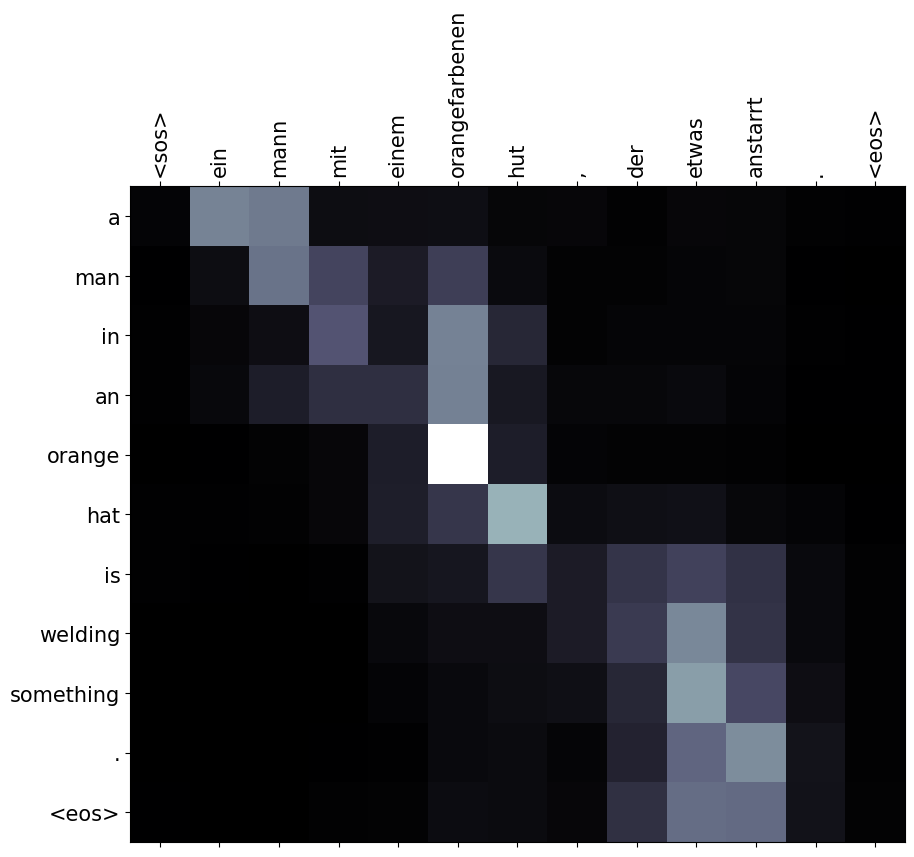

In [38]:
plot_attention(sentence_tokens, translation, attention)

In [39]:
sentence = "Ein Mann sieht sich einen Film an."

In [40]:
translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [41]:
translation

['<sos>', 'a', 'man', 'is', 'looking', 'at', 'a', 'conference', '.', '<eos>']

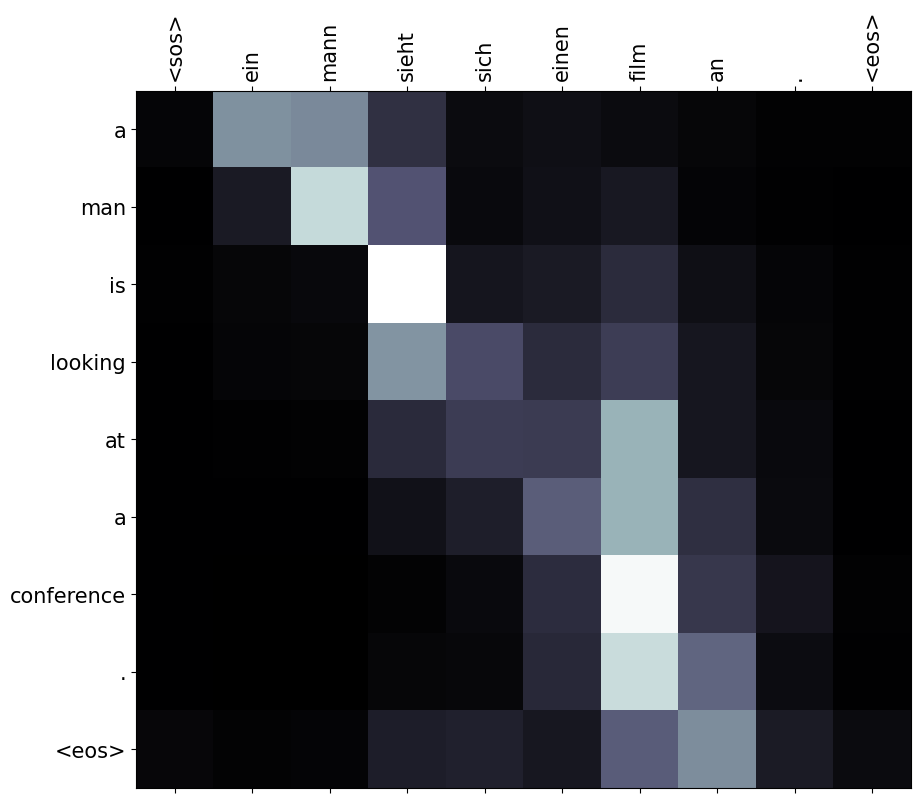

In [42]:
plot_attention(sentence_tokens, translation, attention)

In [43]:
translations = [
    translate_sentence(
        example["de"],
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )[0]
    for example in tqdm.tqdm(test_data)
]

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:19<00:00, 52.49it/s]


In [44]:
bleu = evaluate.load("bleu")

In [45]:
predictions = [" ".join(translation[1:-1]) for translation in translations]

references = [[example["en"]] for example in test_data]

In [46]:
def get_tokenizer_fn(nlp, lower):
    def tokenizer_fn(s):
        tokens = [token.text for token in nlp.tokenizer(s)]
        if lower:
            tokens = [token.lower() for token in tokens]
        return tokens

    return tokenizer_fn

In [47]:
tokenizer_fn = get_tokenizer_fn(en_nlp, lower)

In [48]:
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)

In [49]:
results

{'bleu': 0.2583046682746609,
 'precisions': [0.5782342342342343,
  0.333126213592233,
  0.19528421052631578,
  0.1183448275862069],
 'brevity_penalty': 1.0,
 'length_ratio': 1.0625670087302803,
 'translation_length': 13875,
 'reference_length': 13058}

# Flaw Search
## Large Extreme Test Dataset
**NOTE: The following was copied from my earlier attempt to train on the larger data. This applies for translation testing aas well. Training was abandoned due to hardware limitations and it can be assumed that it may take at least 5 hours to train 1 epoch. Translation testing can take between 15-40 hours.**

<s>
The new dataset has 4592289 training entries. Training on this many entries requires a GPU that allows PyTorch to allocate GBs worth of data in cuda. A `OutOfMemoryError: CUDA out of memory. Tried to allocate <> GiB. GPU` error might/will occur if it cannot allocate the space while training at different epochs. Note that the memory allocation error will be less than your GPUs actual memory. This is the **additional** memory it's trying to allocate, meaning it's likely PyTorch was already utilizing all `x` GB of GPU memory before it ran out of space.

Alternatively, the (adapted) code can be modified to use on multiple GPUs. Please specify below for `training_percentage` to limit the percentage of the full training data to use. If memory is still an issue, adjust teh `batch_size`. Use `torch.cuda.memory_summary(device=None, abbreviated=False)` to see GPU allocation.

For this modified training, a `training_percentage=0.007` will be used alongside a `batch_size=128` such that it's slightly more data than the original implementation. The other reasoning is due to hardware limitations.
</s>

**NOTE: Cropping occurs in the converted dataset, process of converting still iterates through all <s>4592289</s> rows**

In [55]:
# Load new larger de-en dataset
tmp_dataset = datasets.load_dataset("wmt/wmt_t2t") # https://huggingface.co/datasets/wmt/wmt_t2t

# #### MODIFY THIS ACCORDINGLY
large_dataset_percentage = 0.05   # Set to 1.0 for full dataset
# ############################

# Convert dataset to match original schema
large_dataset = None
ens = []
des = []
for subset_name, subset in tmp_dataset.items():
    # Generate random index selection to use in cropped data
    crop_sz = max(int(large_dataset_percentage * subset.shape[0]), 1)
    cropped_random_ids = sample(range(0, subset.shape[0]), crop_sz) if int(large_dataset_percentage) != 1 else []   # If 1.0 -> no crop, don't waste time generating
    cropped_random_ids.sort()   # For random selection performance boost later

    idx_selection_idx = 0 
    selected_indx = cropped_random_ids[idx_selection_idx] if len(cropped_random_ids) != 0 else None
    for i, row in enumerate(tqdm.tqdm(subset, desc=f'Randomly appending {crop_sz} "{subset_name}" data')):   
        # Append en and de sentences. Accessing 'translation' here to skip unpacking step that occurs when iterating through subset['translation']
        if i == selected_indx or selected_indx == None:
            ens.append(row['translation']['en'])
            des.append(row['translation']['de'])
            
            # Update with next crop selected idx if not None (which is no crop)
            if selected_indx != None:
                idx_selection_idx += 1
                selected_indx = cropped_random_ids[idx_selection_idx if idx_selection_idx < crop_sz else 0]

Randomly appending 150 "test" data: 100%|████████████████████████████████████████| 3003/3003 [00:00<00:00, 53432.55it/s]


In [56]:
large_dataset = datasets.Dataset(Table.from_arrays([pa_array(ens), pa_array(des)], names=['en', 'de']))
large_dataset

Dataset({
    features: ['en', 'de'],
    num_rows: 229914
})

In [57]:
# Tokenize Stress Data
fn_kwargs = {
    "en_nlp": en_nlp,
    "de_nlp": de_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}
large_data = large_dataset.map(tokenize_example, fn_kwargs=fn_kwargs)

# Get Token IDS for Stress Data
fn_kwargs = {"en_vocab": en_vocab, "de_vocab": de_vocab}
large_data = large_data.map(numericalize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/229914 [00:00<?, ? examples/s]

Map:   0%|          | 0/229914 [00:00<?, ? examples/s]

In [58]:
large_data = large_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [59]:
model.load_state_dict(torch.load("tut3-model.pt"))

large_translations = [
    translate_sentence(
        example["de"],
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
        max_output_length=int(len(example['de_tokens']) * 1.5)
    )
    for example in tqdm.tqdm(large_data)
]

100%|█████████████████████████████████████████████████████████████████████████| 229914/229914 [1:46:22<00:00, 36.02it/s]


In [60]:
bleu = evaluate.load("bleu")
predictions = [" ".join(translation[0][1:-1]) for translation in large_translations]
references = [[example["en"]] for example in large_data]

In [61]:
tokenizer_fn = get_tokenizer_fn(en_nlp, lower)
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)
results

{'bleu': 0.0008995937985909565,
 'precisions': [0.05903212602030728,
  0.0023228583968887178,
  0.00016949104692028417,
  2.8179150030130015e-05],
 'brevity_penalty': 1.0,
 'length_ratio': 1.7263399119775507,
 'translation_length': 10377756,
 'reference_length': 6011421}

#### Analysis

In [62]:
class Potential_Good_Translations:
    def __init__(self):
        self.results = []
        self.ens = []
        self.wcs = []
        self.uniques = []

    def add_items(self, result, en, wc, unique):
        self.results.append(result)
        self.ens.append(en)
        self.wcs.append(wc)
        self.uniques.append(unique)

    def make_dataframe(self):
        tmp_translations = []
        tmp_sent_tokens = []
        tmp_attentions = []
        
        for result in self.results:
            tmp_translations.append(result[0])
            tmp_sent_tokens.append(result[1])
            tmp_attentions.append(result[2])

        return pd.DataFrame({'translations': tmp_translations, 'sent_tokens': tmp_sent_tokens, 'en': self.ens,
                             'word_count': self.wcs, 'unique_words': self.uniques, 'attentions': tmp_attentions})

In [180]:
from collections import Counter

large_dataset_goods = Potential_Good_Translations()
large_dataset_perfects = Potential_Good_Translations()
large_dataset_filter_stats = [0, 0, 0, 0, 0]   # [filtered results, unfiltered results, 50% strict filtration, 25% great filtration, 0% perfect filtration]
for result, example in zip(tqdm.tqdm(large_translations), large_data):
    translation, sentence_tokens, attention = result
    unk_count = translation.count('<unk>')
    if unk_count / (len(translation) - 2) < 0.75:   # Possibly acceptable
        large_dataset_goods.add_items(result, example['en'], len(translation) - 2 - unk_count, len(Counter(translation).keys()) - 2)
        large_dataset_filter_stats[1] += 1
    else:
        large_dataset_filter_stats[0] += 1

    if unk_count / (len(translation) - 2) < 0.01:   # Possibly perfect
        large_dataset_filter_stats[2] += 1
        large_dataset_filter_stats[3] += 1
        large_dataset_filter_stats[4] += 1
        large_dataset_perfects.add_items(result, example['en'], len(translation) - 2 - unk_count, len(Counter(translation).keys()) - 2)
    elif unk_count / (len(translation) - 2) < 0.25:   # Possibly great
        large_dataset_filter_stats[2] += 1
        large_dataset_filter_stats[3] += 1
    elif unk_count / (len(translation) - 2) < 0.50:   # Possibly good
        large_dataset_filter_stats[2] += 1

100%|█████████████████████████████████████████████████████████████████████████| 229914/229914 [00:56<00:00, 4041.86it/s]


In [197]:
total_results = np.sum(large_dataset_filter_stats[:2])
print(f'{large_dataset_filter_stats[1]} results considered, {large_dataset_filter_stats[0]} results filtered.')
print(large_dataset_filter_stats[1], large_dataset_filter_stats[1] / total_results, 'of the results are possibly acceptable')
print(large_dataset_filter_stats[2], large_dataset_filter_stats[2] / total_results, 'of the results are possibly good')
print(large_dataset_filter_stats[3], large_dataset_filter_stats[3] / total_results, 'of the results are possibly great')
print(large_dataset_filter_stats[4], 'or', large_dataset_filter_stats[4] / total_results, 'of the results are possibly perfect')

111917 results considered, 117997 results filtered.
111917 0.4867776646920153 of the results are possibly acceptable
41926 0.1823551414876867 of the results are possibly good
11274 0.04903572640204598 of the results are possibly great
1428 or 0.0062110180328296665 of the results are possibly perfect


In [152]:
large_dataframe = large_dataset_goods.make_dataframe()
# large_dataframe

In [153]:
large_dataframe_sorted_wc = large_dataframe.sort_values(by='word_count', ascending=False)
large_dataframe_sorted_wc.head()

,translations,sent_tokens,en,word_count,unique_words,attentions
67547,"[<sos>, nine, (, (, (, (, (, (, (, (, (, (, (,...","[<sos>, (, 1, ), u, (, 2, ), u&d, (, 3, ), u(1...","(1) U (2) U"" (3) U$ (4) U$A (5) U$C (6) U$D (7...",1502,2,"[[[tensor(0.0008), tensor(0.1754), tensor(0.00..."
70613,"[<sos>, nine, (, (, (, (, (, (, (, (, (, (, (,...","[<sos>, nw, (, 1119, ), jmc, (, 1120, ), jmd, ...",Whittaker Australia Ltd (1406) J.H. Wilkinson ...,512,2,"[[[tensor(0.0018), tensor(0.2761), tensor(0.00..."
67546,"[<sos>, <unk>, (, (, (, (, (, (, (, (, (, (, (...","[<sos>, sinfonie, (, haydn, ), (, 254, ), 940,...",Grenadier Regiment (886) 9140 Deni (887) 9141 ...,442,2,"[[[tensor(0.0022), tensor(0.3186), tensor(0.01..."
99736,"[<sos>, <unk>, (, (, (, (, (, (, (, (, (, (, (...","[<sos>, sinfonie, (, haydn, ), (, 416, ), 76, ...",1: Da Movement (1041) 713 Luscinia (1042) 713 ...,430,2,"[[[tensor(0.0024), tensor(0.3192), tensor(0.01..."
36069,"[<sos>, <unk>, <unk>, <unk>, <unk>, <unk>, <un...","[<sos>, b4, -, 0295, /, 96, -, 0, -, 0071, /, ...","by Mr Burenstam Linder and Mr Martens, on beha...",420,4,"[[[tensor(0.0016), tensor(0.5247), tensor(0.02..."


In [154]:
print('length:', len(large_dataframe['sent_tokens'][36069]))
print(' '.join(large_dataframe['sent_tokens'][36069]))
print()
large_dataframe['en'][36069]

length: 333
<sos> b4 - 0295 / 96 - 0 - 0071 / 96 der abgeordneten burenstam linder und martens im namen der ppe-fraktion an den rat und b4 - 0296 / 96 - 0 - 0072 / 96 an die kommission zum ostseegipfel in visby ; -b4 - 0297 / 96 - 0 - 0078 / 96 der abgeordneten olsson , kofoed , o. rehn und de vries im namen der eldr-fraktion an die kommission zum gipfeltreffen der ostseestaaten in visby am 3. und 4. mai 1996 ; -b4 - 0298 / 96 - 0 - 0080 / 96 der abgeordneten roth , aelvoet , gahrton , schroedter und hautala im namen der v-fraktion an den rat und b4 - 0299 / 96 - 0 - 0081 / 96 an die kommission zum gipfeltreffen der ostseeanrainerstaaten ; -b4 - 0300 / 96 - 0 - 0082 / 96 der abgeordneten stenius-kaukonen im namen der gue / nglfraktion an den rat und b4 - 0425 / 96 - 0 - 0083 / 96 an die kommission zum gipfeltreffen in visby über die baltische region ; -b4 - 0426 / 96 - 0 - 0088 / 96 der abgeordneten lalumière im namen der are-fraktion an den rat zum gipfeltreffen der ostseeanrainerstaa

"by Mr Burenstam Linder and Mr Martens, on behalf of the Group of the European People's Party, to the Council (B4-0295/96 - O-0071/96) and to the Commission (B4-0296/96 -O-0072/96) on the Visby Summit on the Baltic region; -by Mr Olsson and others, on behalf of the European Liberal, Democratic and Reformist Party, to the Commission (B4-0297/96 - O-0078/96) on the Summit of Baltic States, 3 and 4 May 1996, in Visby; -by Mrs Roth and others, on behalf of the Green Group in the European Parliament, to the Council (B4-0298/96 - O-0080/96) and to the Commission (B40299/96 - O-0081/96) on the Baltic Summit; -by Mrs Stenius-Kaukonen, on behalf of the Confederal Group of the European United Left - Nordic Green Left, to the Council (B4-0300/96 - O-0082/96) and to the Commission (B4-0425/96 - O-0083/96) on the Visby Summit on the Baltic region; -by Mrs Lalumière, on behalf of the Group of the European Radical Alliance, to the Council (B4-0426 -O-0088/96) on the Summit on the Baltic Sea; -by Mrs 

DE: <sos> b4 - 0295 / 96 - 0 - 0071 / 96 der abgeordneten burenstam linder und martens im namen der ppe-fraktion an den rat und b4 - 0296 / 96 - 0 - 0072 / 96 an die kommission zum ostseegipfel in visby ; -b4 - 0297 / 96 - 0 - 0078 / 96 der abgeordneten olsson , kofoed , o. rehn und de vries im namen der eldr-fraktion an die kommission zum gipfeltreffen der ostseestaaten in visby am 3. und 4. mai 1996 ; -b4 - 0298 / 96 - 0 - 0080 / 96 der abgeordneten roth , aelvoet , gahrton , schroedter und hautala im namen der v-fraktion an den rat und b4 - 0299 / 96 - 0 - 0081 / 96 an die kommission zum gipfeltreffen der ostseeanrainerstaaten ; -b4 - 0300 / 96 - 0 - 0082 / 96 der abgeordneten stenius-kaukonen im namen der gue / nglfraktion an den rat und b4 - 0425 / 96 - 0 - 0083 / 96 an die kommission zum gipfeltreffen in visby über die baltische region ; -b4 - 0426 / 96 - 0 - 0088 / 96 der abgeordneten lalumière im namen der are-fraktion an den rat zum gipfeltreffen der ostseeanrainerstaaten ; -b

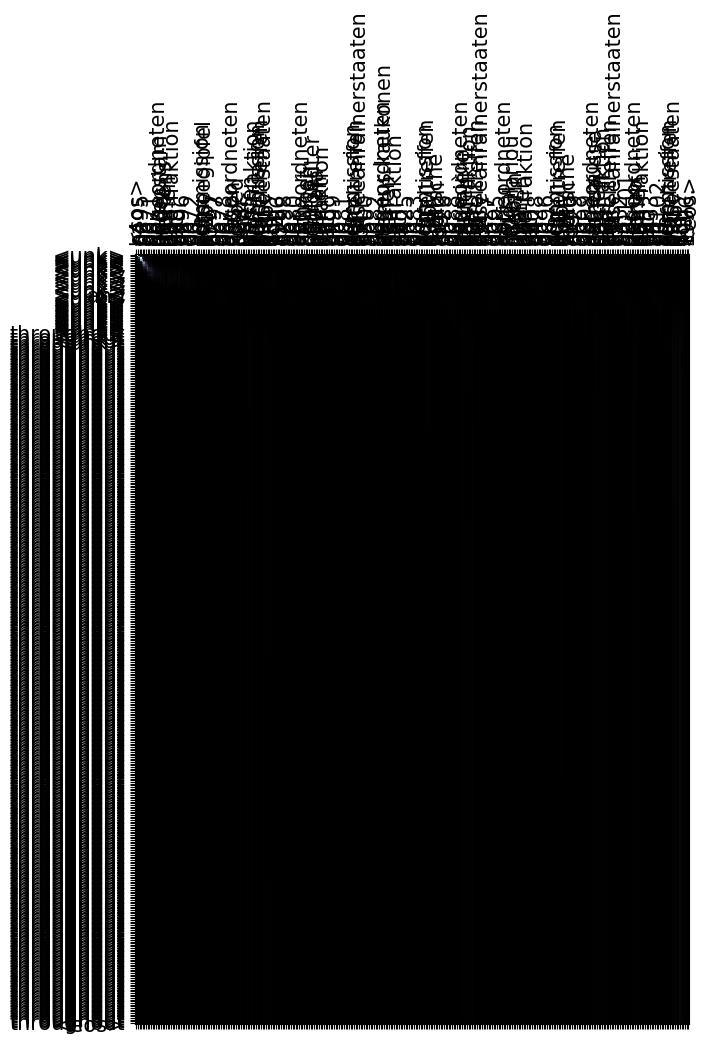

In [155]:
for i, row in large_dataframe_sorted_wc.head().iterrows():
    if i != 36069: continue   # Used to skip the unexpected translation cases
    
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

In [156]:
large_dataframe_sorted_unique = large_dataframe.sort_values(by='unique_words', ascending=False)
large_dataframe_sorted_unique.head()

,translations,sent_tokens,en,word_count,unique_words,attentions
73380,"[<sos>, <unk>, <unk>, <unk>, <unk>, <unk>, ,, ...","[<sos>, fremantles, großartige, historische, a...",Locals here enjoy a relaxed outdoors lifestyle...,30,19,"[[[tensor(0.0049), tensor(0.6465), tensor(0.08..."
49134,"[<sos>, the, sun, are, their, <unk>, ,, and, <...","[<sos>, verbringen, sie, ihren, tag, mit, tisc...","After a day of ping pong and archery, unwind i...",22,18,"[[[tensor(0.0083), tensor(0.0902), tensor(0.44..."
52558,"[<sos>, <unk>, <unk>, a, a, photo, ,, as, he, ...","[<sos>, normalerweise, bekommen, sie, einen, t...",Normally one plate per group but if you are in...,20,18,"[[[tensor(0.0052), tensor(0.8559), tensor(0.04..."
38822,"[<sos>, these, people, hold, what, appears, to...","[<sos>, diese, menschen, halten, uns, nicht, i...",These people are not holding out a begging bow...,22,17,"[[[tensor(0.0014), tensor(0.9690), tensor(0.00..."
31132,"[<sos>, nine, <unk>, women, (, <unk>, <unk>, ,...","[<sos>, (, fr, ), frau, präsidentin, ,, meine,...","(FR) Madam President, ladies and gentlemen, we...",25,17,"[[[tensor(0.0032), tensor(0.9468), tensor(0.01..."


DE: <sos> fremantles großartige historische architektur versetzt sie zurück in eine andere zeit , während die vielen wassersportmöglichkeiten sie hinaus aufs meer bringen , wie z.b. eine kurze fahrt mit der fähre zur nahe gelegenen rottnest insel . <eos>
EN: <sos> Locals here enjoy a relaxed outdoors lifestyle, as does the neighbouring port city of Fremantle , at the mouth of the Swan River. <eos>
TR: <sos> <unk> <unk> <unk> <unk> <unk> , as they are a a , as they are seen from the sea , , a a long - o - war near the end of the water . <eos>


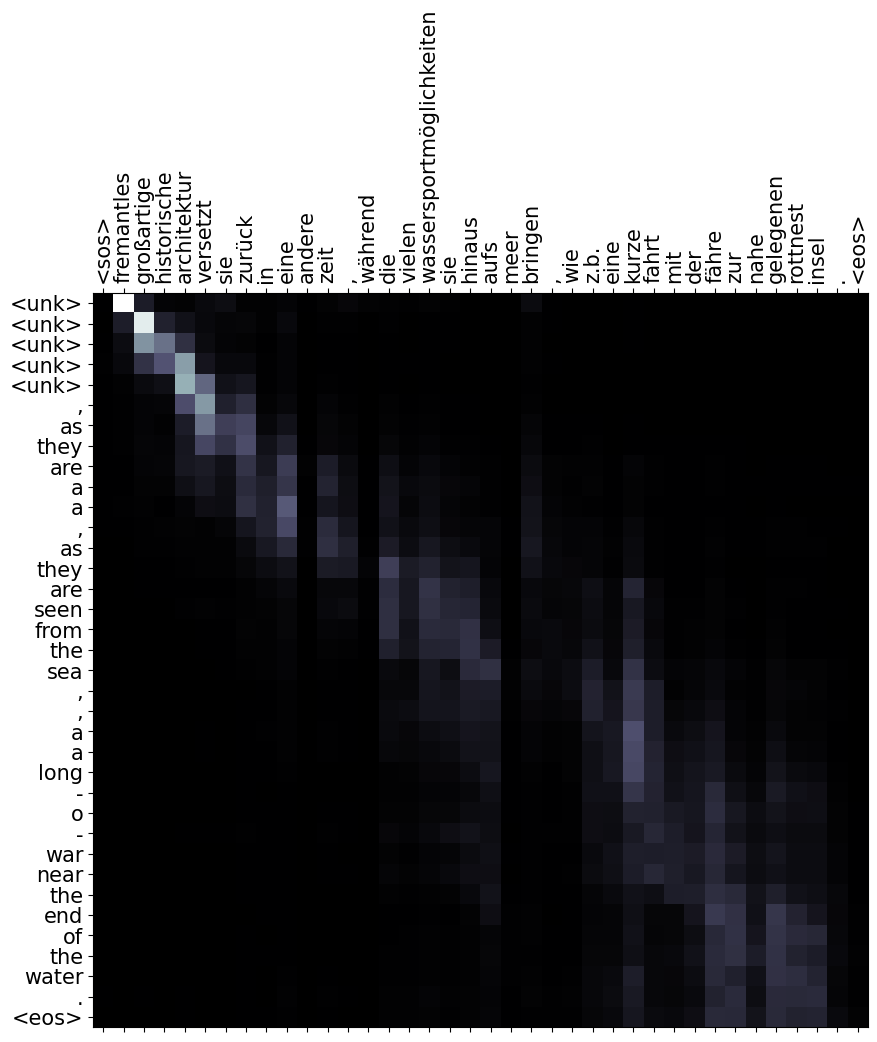

DE: <sos> verbringen sie ihren tag mit tischtennis spielen und bogenschießen oder entspannen sie in der sauna bevor sie abends eine delikate mahlzeit im restaurant genießen . anschließend können sie sich in der victoria lounge eine show ansehen . <eos>
EN: <sos> After a day of ping pong and archery, unwind in the hotel’s sauna before a delicious meal in the restaurant followed by a show in the Victoria Lounge. <eos>
TR: <sos> the sun are their <unk> , and <unk> , play in the <unk> , most appears to be a at the outdoor outdoor game . <eos>


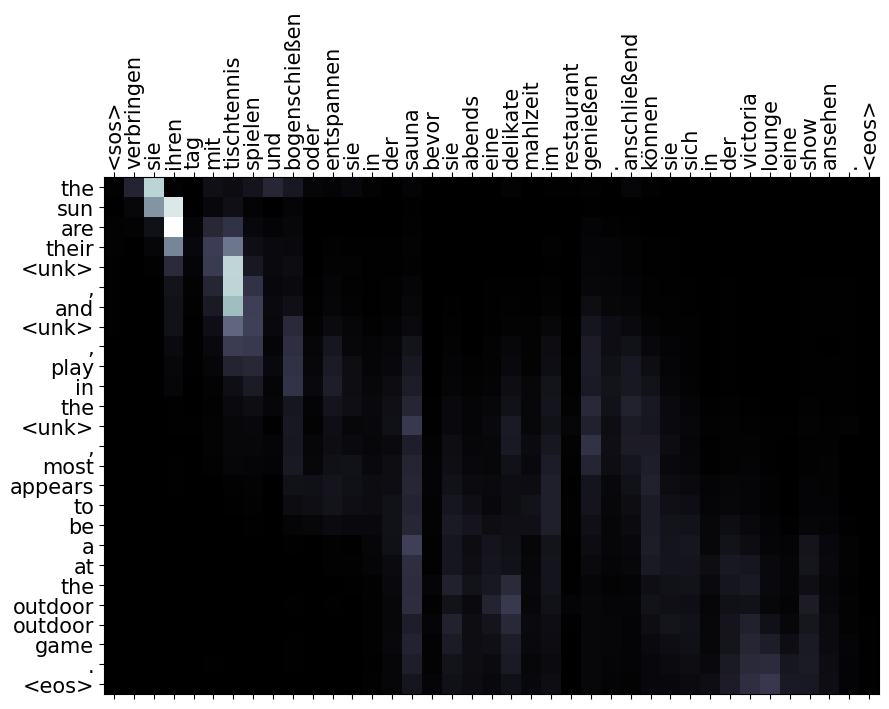

DE: <sos> normalerweise bekommen sie einen teller pro gruppe aber wenn sie eine große gruppe haben , dann müssen sie wahrscheinlich mehrere teller bestellen . <eos>
EN: <sos> Normally one plate per group but if you are in a large group you may have to request additional plates. <eos>
TR: <sos> <unk> <unk> a a photo , as he is surrounded by a large , who are ready to be some people . <eos>


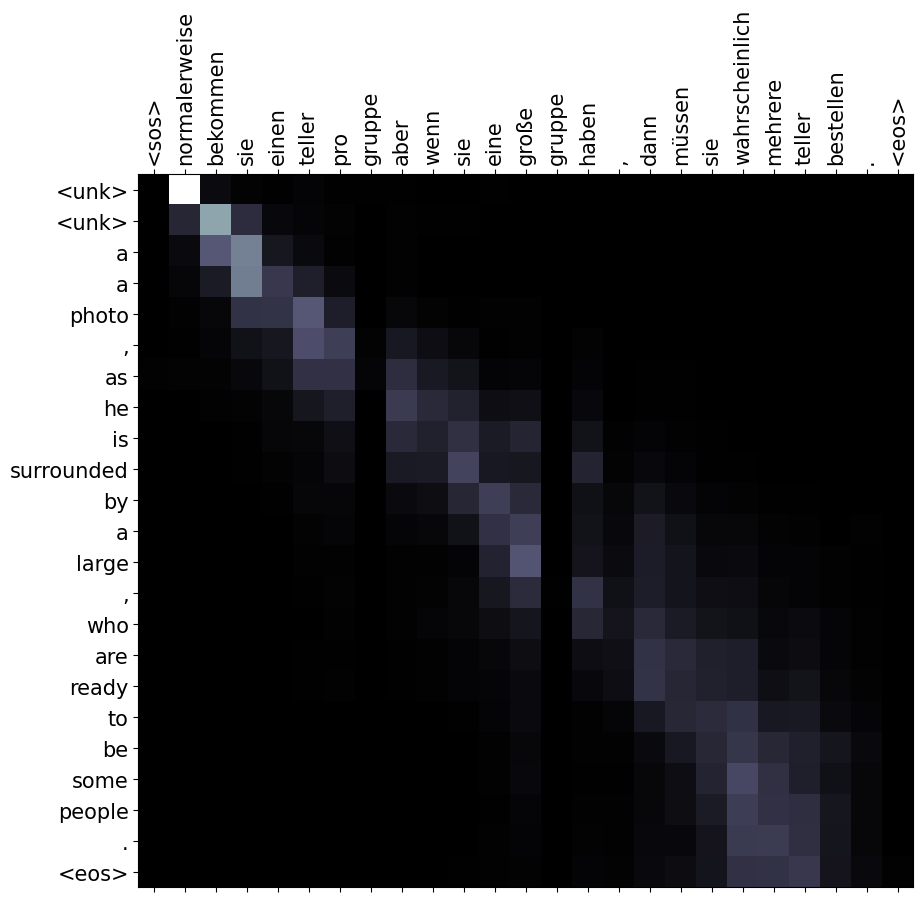

DE: <sos> diese menschen halten uns nicht ihre hand zum betteln entgegen , sie fordern nur die anerkennung , daß sie kleine landbesitzende demokratien in ländern haben , die menschenrechte achten und die rechte der arbeitnehmer schützen . <eos>
EN: <sos> These people are not holding out a begging bowl - they are only asking for recognition that they have small landowning democracies in countries which have human rights and which protect workers' rights. <eos>
TR: <sos> these people hold what appears to be their hands , they are <unk> , will <unk> , they are will <unk> and the the . <eos>


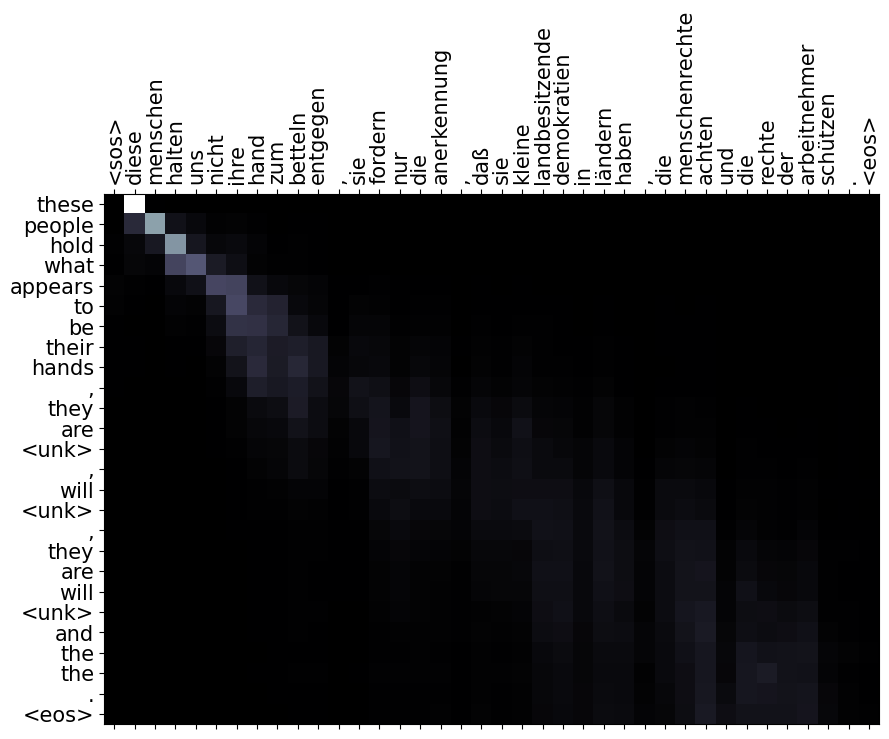

DE: <sos> ( fr ) frau präsidentin , meine damen und herren ! wir müssen zugeben , dass es beklagenswert ist , dass wir , nachdem wir zwei drittel des weges zurückgelegt haben , so weit davon entfernt sind , die anfänglichen durch die millenniums-entwicklungsziele festgesetzten zielsetzungen zu erreichen . <eos>
EN: <sos> (FR) Madam President, ladies and gentlemen, we must admit it is deplorable that two-thirds of the way along we should be so far from achieving the original objectives set by the Millennium Development Goals. <eos>
TR: <sos> nine <unk> women ( <unk> <unk> , and glasses , appear to be so so so the the the street , possibly the arrival of the street . <eos>


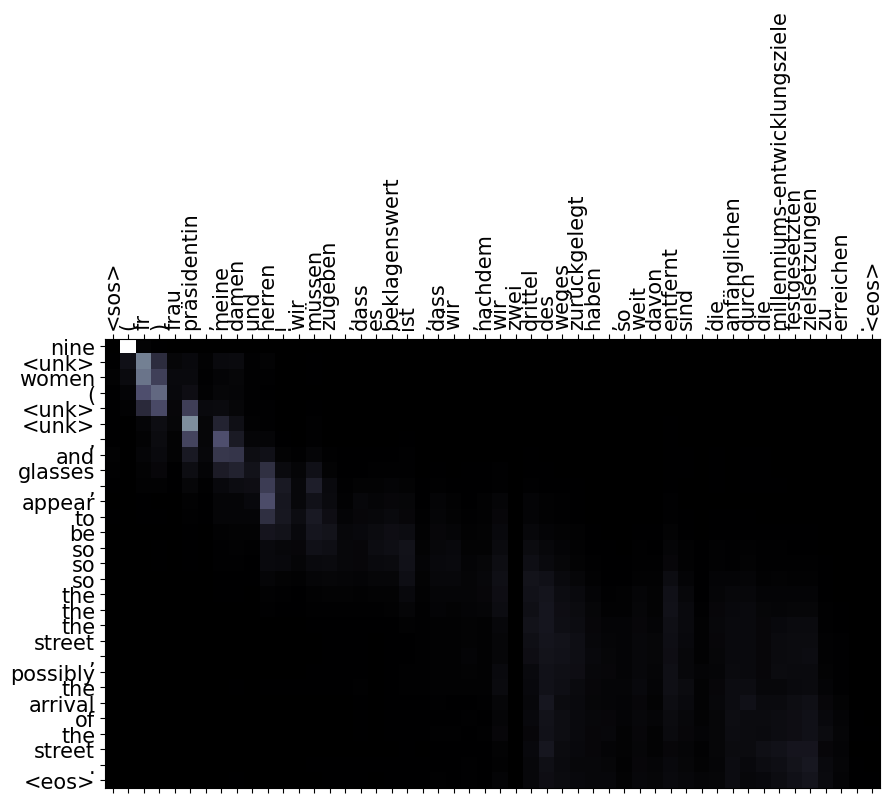

In [157]:
for _, row in large_dataframe_sorted_unique.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

DE: <sos> das hotel liegt auf einem 1 hektar großen grundstück und besteht aus 2 gebäuden . <eos>
EN: <sos> The hotel is set in an acre of grounds and is comprised of 2 buildings. <eos>
TR: <sos> the is laying on the top of a heavily square , with several buildings and buildings . <eos>


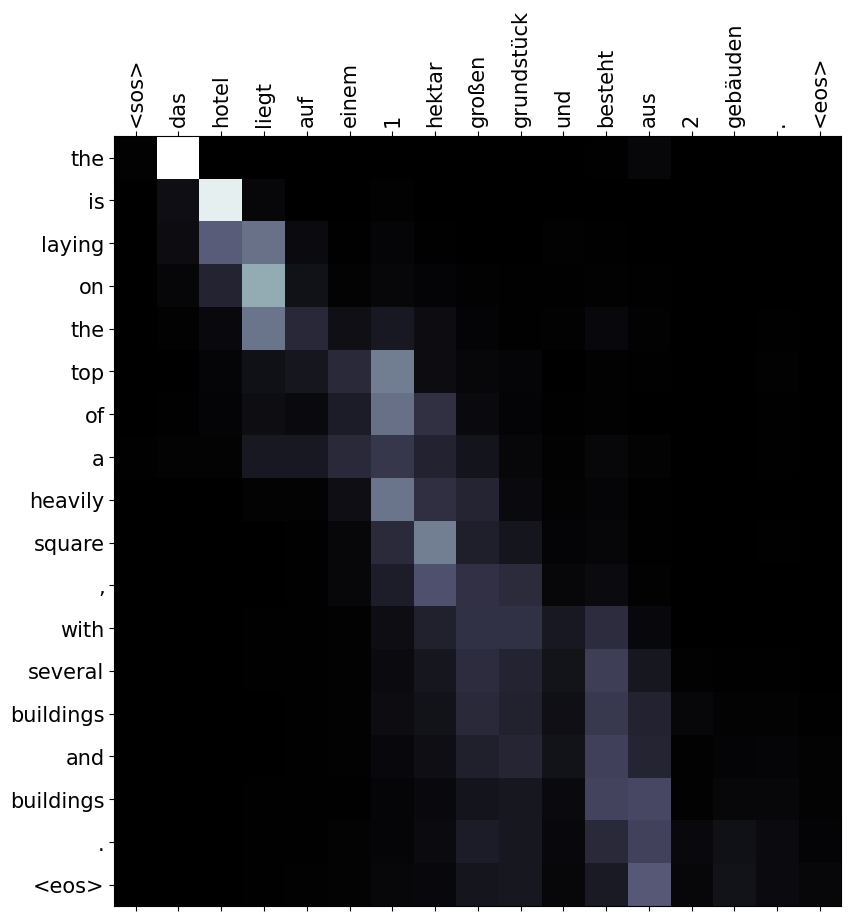

DE: <sos> wenn du leute per email zu diesen fotos einlädst , dann können auch diese leute alle fotos dieser slideshow sehen . weitere möglichkeiten , um auf einen klick fotos für eine ganze gruppe von leuten freizugeben , sind zur zeit noch in arbeit . <eos>
EN: <sos> " there are three settings which allow you to specify the level of access to your SlideShows and the photos they contain. <eos>
TR: <sos> there are many people are pictured , take pictures , three people , are photographed , are pictured , are taking pictures of people are surrounded by . <eos>


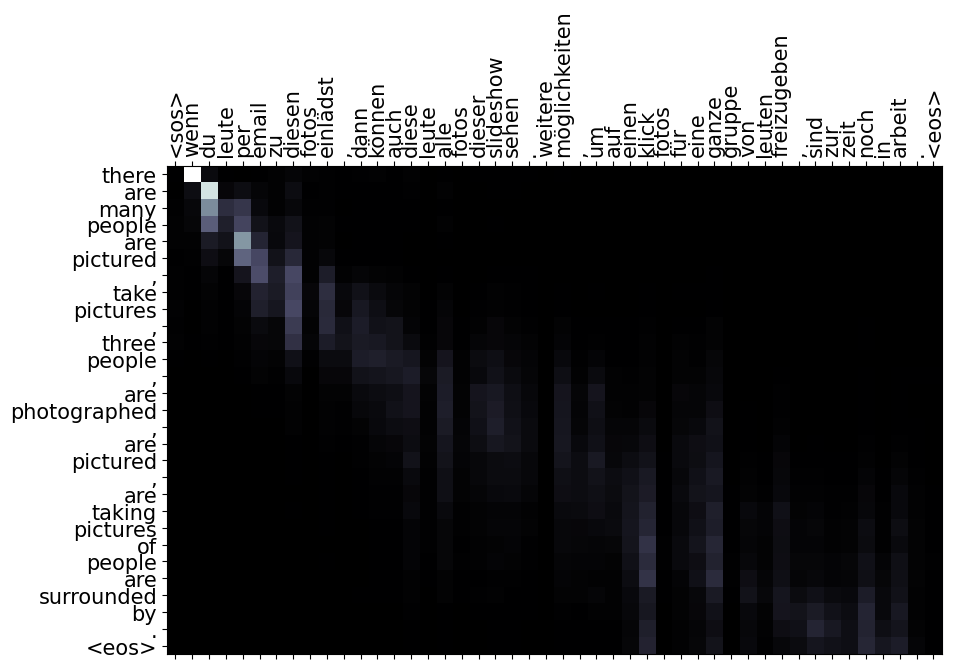

DE: <sos> sie arbeiten hart und zahlen ihre steuern , und ein guter teil davon geht an brüssel . <eos>
EN: <sos> They work hard and they pay their taxes and a good portion of that is sent out to Brussels. <eos>
TR: <sos> she working construction workers and their clothes are working and a , they are walking by them . <eos>


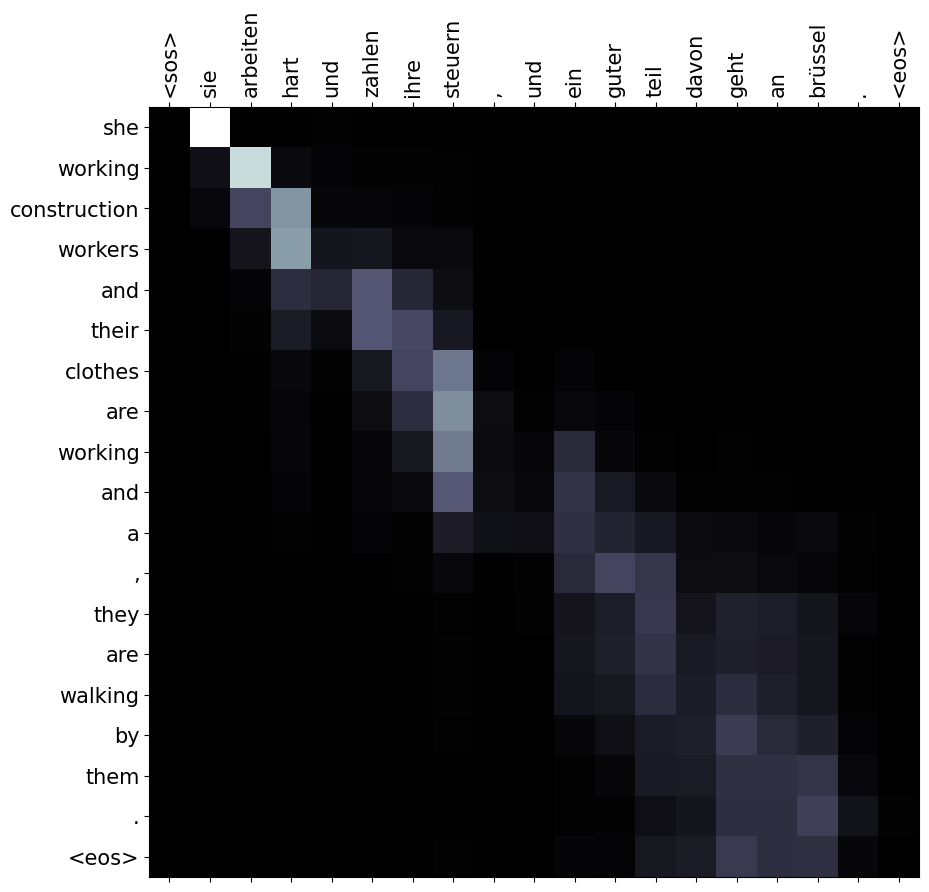

DE: <sos> sie ließen sie dort hängen , damit alle leute sehen konnten , dass die neue autorität ordnung schaffen wollte . <eos>
EN: <sos> They left them for people to see that new authority call for order. <eos>
TR: <sos> they are bent out of people , as they prepare to allow the new york . <eos>


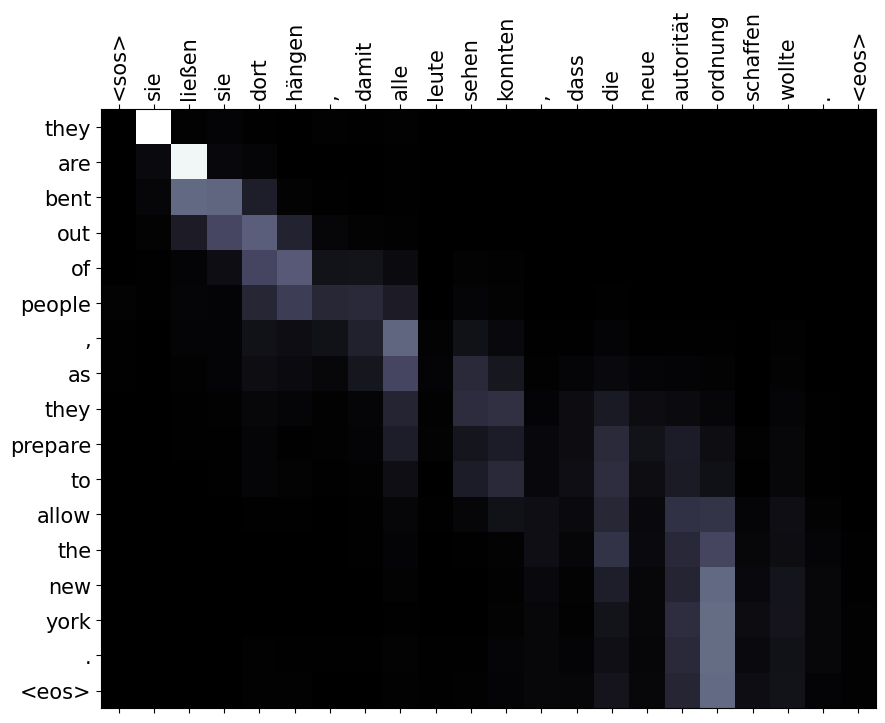

DE: <sos> in der stadt gibt es ein gut ausgebautes netz von bussen . <eos>
EN: <sos> The town's Stara čaršija (old quarter) contains several attractions, including a synagogue, which is now the City Museum and Art Gallery. There is also a mosque (Čaršijska mosque), an Austrian fountain, and an old bey's farm house (Hadžimazića House). <eos>
TR: <sos> the sun is coming up to a a , as they are coming out of . <eos>


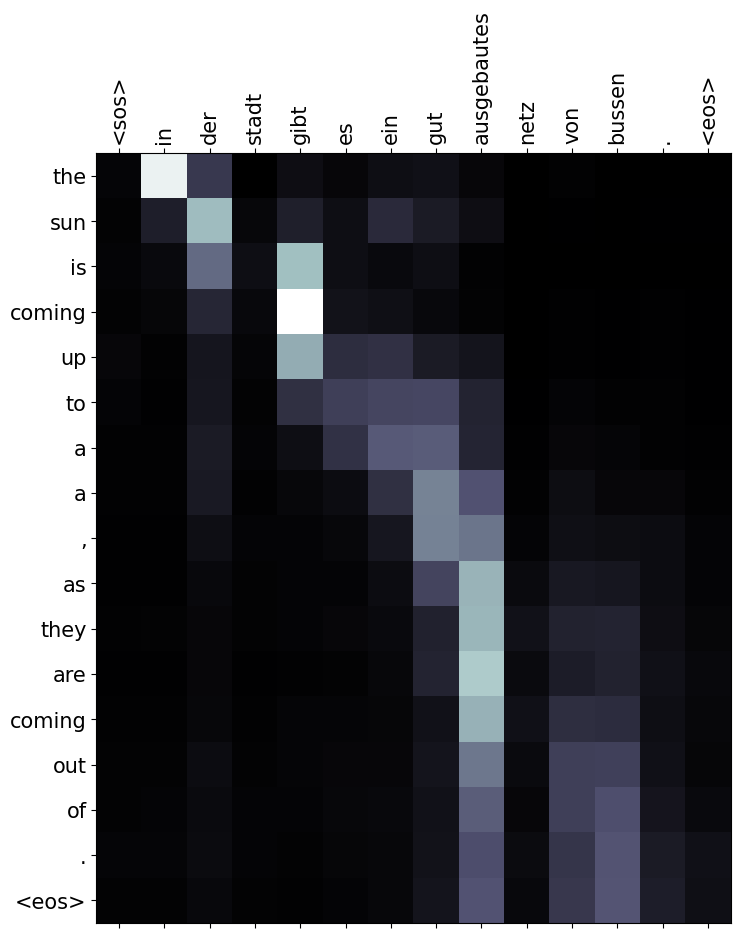

In [199]:
large_perfects_dataframe = large_dataset_perfects.make_dataframe()
large_perfects_dataframe_sorted = large_perfects_dataframe.sort_values(by='unique_words', ascending=False)
for _, row in large_perfects_dataframe_sorted.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

In [208]:
large_perfects_dataframe_sorted.head()

,translations,sent_tokens,en,word_count,unique_words,attentions
728,"[<sos>, the, is, laying, on, the, top, of, a, ...","[<sos>, das, hotel, liegt, auf, einem, 1, hekt...",The hotel is set in an acre of grounds and is ...,17,15,"[[[tensor(0.0112), tensor(0.9224), tensor(0.00..."
761,"[<sos>, there, are, many, people, are, picture...","[<sos>, wenn, du, leute, per, email, zu, diese...",""" there are three settings which allow you to ...",28,15,"[[[tensor(0.0043), tensor(0.8084), tensor(0.03..."
388,"[<sos>, she, working, construction, workers, a...","[<sos>, sie, arbeiten, hart, und, zahlen, ihre...",They work hard and they pay their taxes and a ...,18,15,"[[[tensor(0.0018), tensor(0.9494), tensor(0.00..."
954,"[<sos>, they, are, bent, out, of, people, ,, a...","[<sos>, sie, ließen, sie, dort, hängen, ,, dam...",They left them for people to see that new auth...,16,15,"[[[tensor(0.0032), tensor(0.9006), tensor(0.01..."
601,"[<sos>, the, sun, is, coming, up, to, a, a, ,,...","[<sos>, in, der, stadt, gibt, es, ein, gut, au...",The town's Stara čaršija (old quarter) contain...,16,14,"[[[tensor(0.0163), tensor(0.6153), tensor(0.16..."


In [206]:
large_perfects_dataframe_sorted['word_count'].value_counts()

word_count
9       224
8       214
10      209
11      159
12      115
13       77
7        74
6        71
14       56
3        40
15       33
16       31
17       19
18       15
21       13
19       10
20        9
5         8
22        7
23        6
27        5
26        4
24        4
25        4
36        2
33        2
139       1
1502      1
119       1
148       1
410       1
430       1
512       1
57        1
34        1
47        1
28        1
41        1
30        1
32        1
42        1
31        1
442       1
Name: count, dtype: int64

## Complexity/Stress Test Dataset

In [158]:
# Load complex de-en dataset. Dataset from https://www.manythings.org/anki/
complex_dataset = pd.read_csv('deu-eng/deu.txt', names=['en', 'de', 'ack'], sep='\t', header=None).dropna()
complex_dataset['word_count'] = complex_dataset['de'].apply(lambda x: (len(x.split())) + 1)
complex_dataset['complexity'] = complex_dataset['de'].apply(lambda x: (len(x.split()) // 25) + 1)
stress_eval_dataset = datasets.Dataset(Table.from_pandas(complex_dataset[['en', 'de', 'complexity']]))
stress_eval_dataset

Dataset({
    features: ['en', 'de', 'complexity'],
    num_rows: 277891
})

In [159]:
# Tokenize Stress Data
fn_kwargs = {
    "en_nlp": en_nlp,
    "de_nlp": de_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}
stress_data = stress_eval_dataset.map(tokenize_example, fn_kwargs=fn_kwargs)

# Get Token IDS for Stress Data
fn_kwargs = {"en_vocab": en_vocab, "de_vocab": de_vocab}
stress_data = stress_data.map(numericalize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/277891 [00:00<?, ? examples/s]

Map:   0%|          | 0/277891 [00:00<?, ? examples/s]

In [160]:
stress_data = stress_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [161]:
model.load_state_dict(torch.load("tut3-model.pt"))

stress_translations = [
    translate_sentence(
        example["de"],
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
        max_output_length=int(len(example['de_tokens']) * 1.5)
    )
    for example in tqdm.tqdm(stress_data)
]

100%|█████████████████████████████████████████████████████████████████████████| 277891/277891 [1:07:56<00:00, 68.17it/s]


In [162]:
bleu = evaluate.load("bleu")
predictions = [" ".join(translation[0][1:-1]) for translation in stress_translations]
references = [[example["en"]] for example in stress_data]

In [163]:
tokenizer_fn = get_tokenizer_fn(en_nlp, lower)
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)
results

{'bleu': 0.006854207300350306,
 'precisions': [0.10607822878100977,
  0.01094258373866966,
  0.0027093062084453086,
  0.0007018183354992763],
 'brevity_penalty': 1.0,
 'length_ratio': 2.148625304883154,
 'translation_length': 4619553,
 'reference_length': 2150004}

#### Analysis

In [164]:
class PGT_Stress(Potential_Good_Translations):
    def __init__(self):
        super().__init__()
        self.complexities = []

    def add_items(self, result, en, wc, unique, complexity):
        super().add_items(result, en, wc, unique)
        self.complexities.append(complexity)

    def make_dataframe(self):
        tmp_df = super().make_dataframe()
        tmp_df['complexities'] = self.complexities

        return tmp_df

In [182]:
stress_dataset_goods = PGT_Stress()
stress_dataset_perfects = PGT_Stress()
stress_dataset_filter_stats = [0, 0, 0, 0, 0]   # [filtered results, unfiltered results, 50% strict filtration, 25% great filtration, 0% perfect filtration]
for result, example in zip(tqdm.tqdm(stress_translations), stress_data):
    translation, sentence_tokens, attention = result
    unk_count = translation.count('<unk>')
    if (unk_count / (len(translation) - 2) < 0.75 and np.abs(len(sentence_tokens) - len(translations) < 5)) or example['complexity'] > 1:   # Possibly acceptable
        stress_dataset_goods.add_items(result, example['en'], len(translation) - 2 - unk_count, 
                                       len(Counter(translation).keys()) - 2, example['complexity'])
        stress_dataset_filter_stats[1] += 1
    else:
        stress_dataset_filter_stats[0] += 1

    if unk_count / (len(translation) - 2) < 0.01:   # Possibly perfect
        stress_dataset_filter_stats[2] += 1
        stress_dataset_filter_stats[3] += 1
        stress_dataset_filter_stats[4] += 1
        stress_dataset_perfects.add_items(result, example['en'], len(translation) - 2 - unk_count, 
                                       len(Counter(translation).keys()) - 2, example['complexity'])
    elif unk_count / (len(translation) - 2) < 0.25:   # Possibly perfect
        stress_dataset_filter_stats[2] += 1
        stress_dataset_filter_stats[3] += 1
    elif unk_count / (len(translation) - 2) < 0.50:   # Possibly good
        stress_dataset_filter_stats[2] += 1

100%|█████████████████████████████████████████████████████████████████████████| 277891/277891 [01:09<00:00, 3991.01it/s]


In [195]:
total_stress_results = np.sum(stress_dataset_filter_stats[:2])
print(f'{stress_dataset_filter_stats[1]} results considered, {stress_dataset_filter_stats[0]} results filtered.')
print(stress_dataset_filter_stats[1], stress_dataset_filter_stats[1] / total_stress_results, 'of the results are possibly acceptable')
print(stress_dataset_filter_stats[2], stress_dataset_filter_stats[2] / total_stress_results, 'of the results are possibly good')
print(stress_dataset_filter_stats[3], stress_dataset_filter_stats[3] / total_stress_results, 'of the results are possibly great')
print(stress_dataset_filter_stats[4], 'or', stress_dataset_filter_stats[4] / total_stress_results, 'of the results are possibly perfect')

228758 results considered, 49133 results filtered.
228758 0.8231932664246053 of the results are possibly acceptable
159789 0.5750060275431734 of the results are possibly good
85940 0.3092579464610225 of the results are possibly great
30203 or 0.10868649938285155 of the results are possibly perfect


In [168]:
stress_dataframe = stress_dataset_goods.make_dataframe()
# stress_dataframe

In [169]:
stress_dataframe_sorted_wc = stress_dataframe.sort_values(by='word_count', ascending=False)
stress_dataframe_sorted_wc.head()

,translations,sent_tokens,en,word_count,unique_words,attentions,complexities
228479,"[<sos>, <unk>, <unk>, <unk>, to, be, <unk>, ,,...","[<sos>, tom, wälzte, sich, um, 6.30, uhr, aus,...","Tom rolled out of bed at 6:30, shuffled into t...",32,11,"[[[tensor(0.0057), tensor(0.8118), tensor(0.03...",1
228063,"[<sos>, <unk>, james, <unk>, <unk>, ,, ,, the,...","[<sos>, maria, hat, tom, dabei, erwischt, ,, w...","Mary caught Tom prying into her diary, trying ...",27,8,"[[[tensor(0.0040), tensor(0.8468), tensor(0.02...",1
217996,"[<sos>, we, <unk>, to, make, <unk>, to, tell, ...","[<sos>, ich, wette, ,, ihr, werdet, mir, sagen...",I bet you're going to tell me you're too tired...,26,6,"[[[tensor(0.0010), tensor(0.9636), tensor(0.02...",1
228691,"[<sos>, many, <unk>, of, young, boys, are, <un...","[<sos>, viele, gepiercte, jugendliche, bleiben...",Many young people with piercings stay together...,26,15,"[[[tensor(0.0705), tensor(0.5760), tensor(0.16...",2
228564,"[<sos>, <unk>, <unk>, <unk>, <unk>, ,, <unk>, ...","[<sos>, tom, nahm, zwei, bierflaschen, aus, de...",Tom took two bottles of beer out of the fridge...,25,5,"[[[tensor(0.0090), tensor(0.7297), tensor(0.10...",1


DE: <sos> tom wälzte sich um 6.30 uhr aus dem bett , schlurfte in die küche und steckte zwei scheiben brot in den toaster . <eos>
EN: <sos> Tom rolled out of bed at 6:30, shuffled into the kitchen and put two slices of bread into the toaster. <eos>
TR: <sos> <unk> <unk> <unk> to be <unk> , the children , they are in the kitchen , two asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian


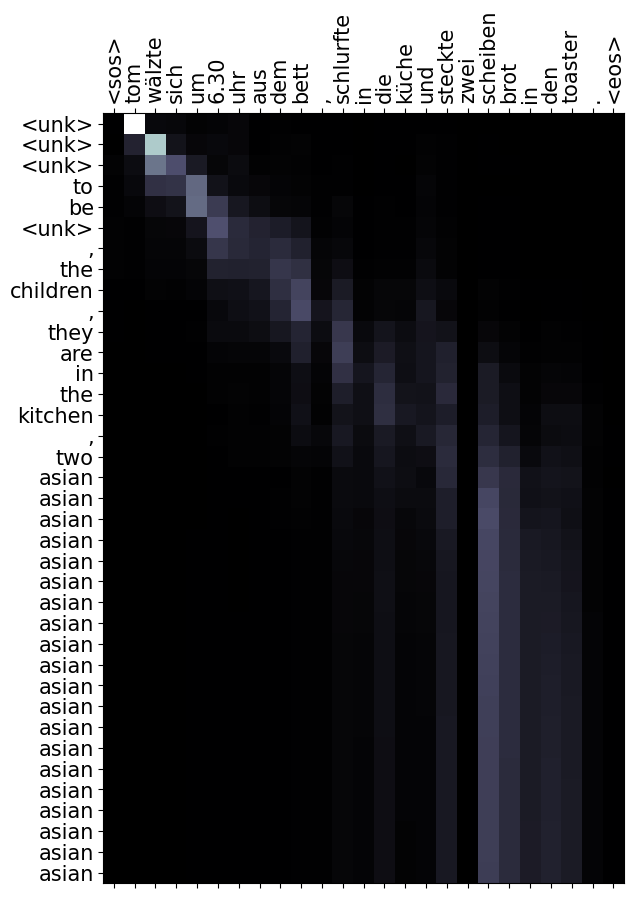

DE: <sos> maria hat tom dabei erwischt , wie er in ihrem tagebuch herumschnüffelte , um herauszufinden , ob sie sich noch mit jemand anderem traf . <eos>
EN: <sos> Mary caught Tom prying into her diary, trying to find out if she was seeing someone else. <eos>
TR: <sos> <unk> james <unk> <unk> , , the , , , in the <unk> , , , , , , , , , , , , , , , and a . <eos>


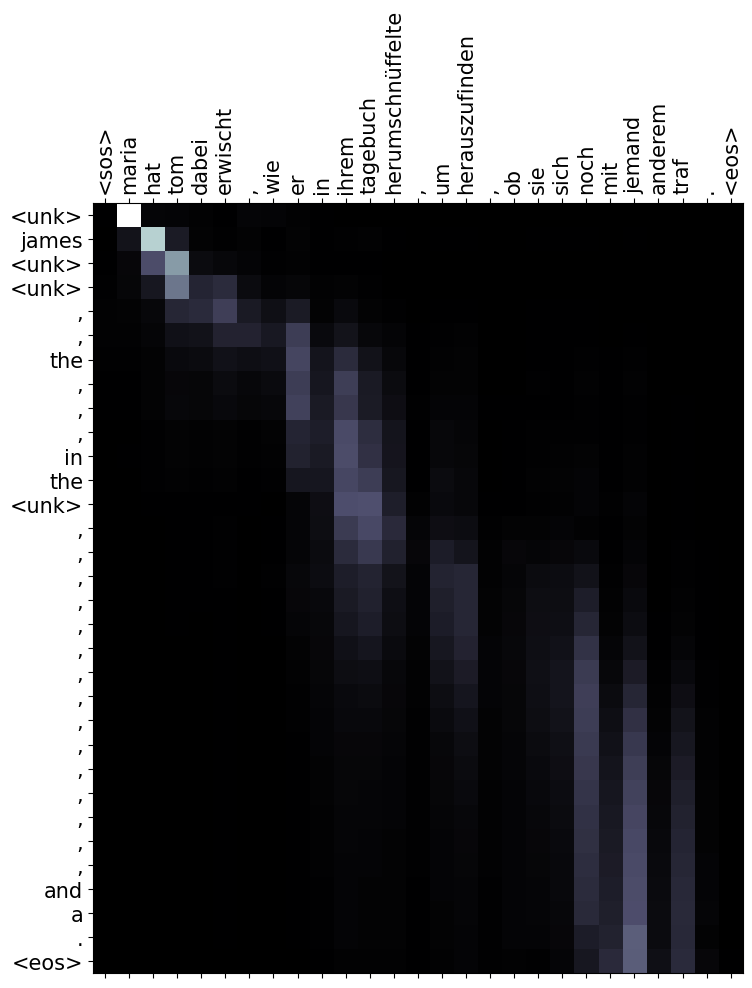

DE: <sos> ich wette , ihr werdet mir sagen , dass ihr zu müde seid , um zu helfen . <eos>
EN: <sos> I bet you're going to tell me you're too tired to help. <eos>
TR: <sos> we <unk> to make <unk> to tell to to to to to to to to to to to to to to to to to to to to . <eos>


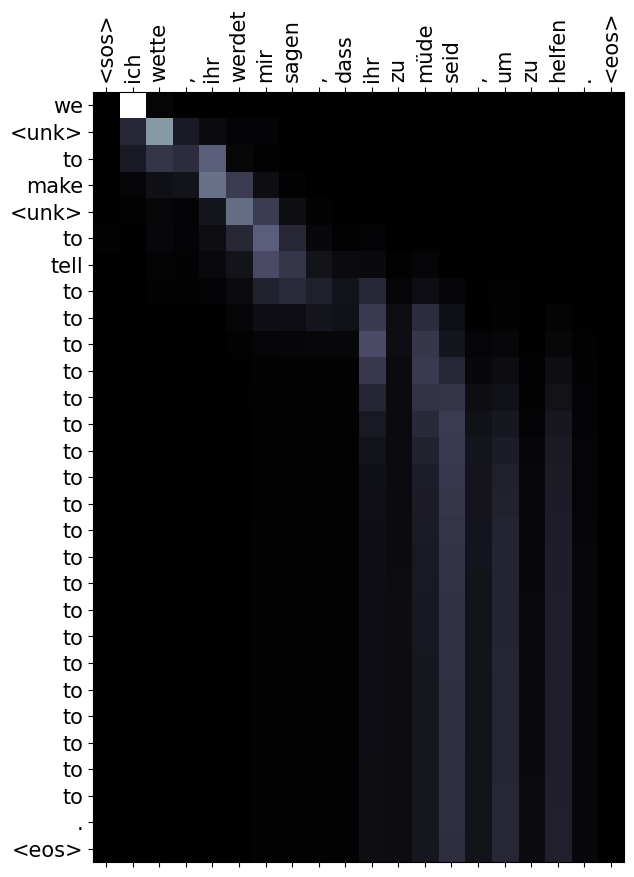

DE: <sos> viele gepiercte jugendliche bleiben mit dem partner ein leben lang zusammen – besonders wenn sich der nasenring des einen in der zahnspange des anderen verfangen hat ! <eos>
EN: <sos> Many young people with piercings stay together their whole lives, especially if one gets their nose ring stuck in the other's braces. <eos>
TR: <sos> many <unk> of young boys are <unk> to <unk> , one a , , one is holding a <unk> , one of the other , one is the other . <eos>


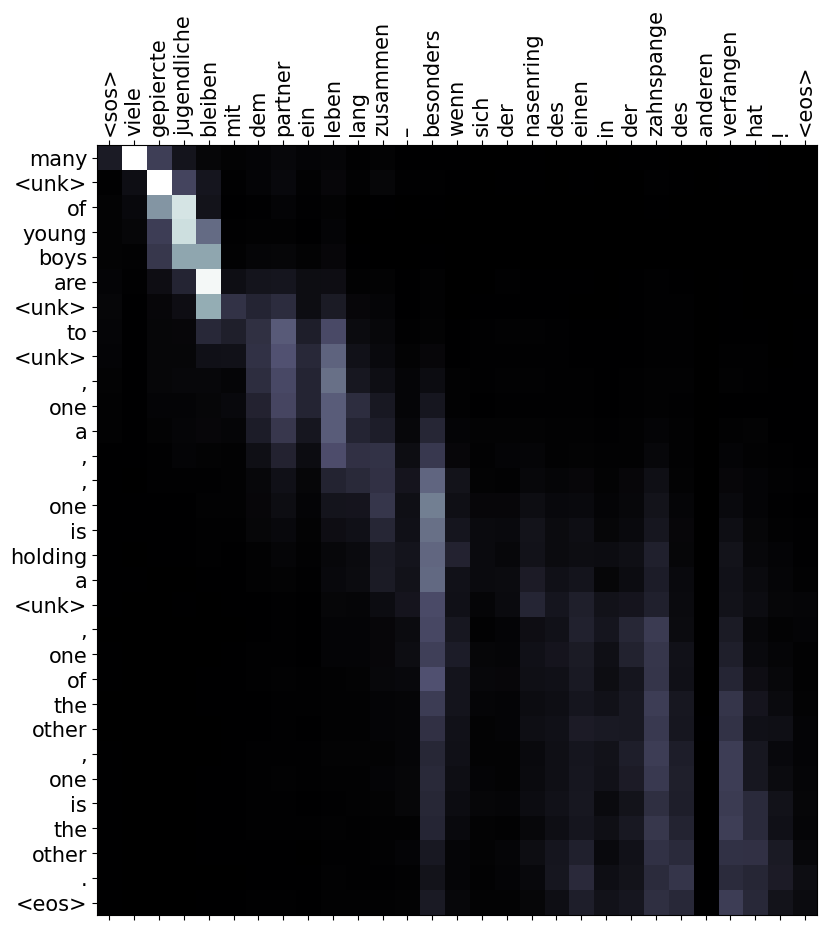

DE: <sos> tom nahm zwei bierflaschen aus dem kühlschrank , eine für sich und eine für johannes , und stellte sie auf den tisch . <eos>
EN: <sos> Tom took two bottles of beer out of the fridge, one for himself and one for John, and put them on the table. <eos>
TR: <sos> <unk> <unk> <unk> <unk> , <unk> , and a , and a and and and and and and and and and and and and and and and and and . <eos>


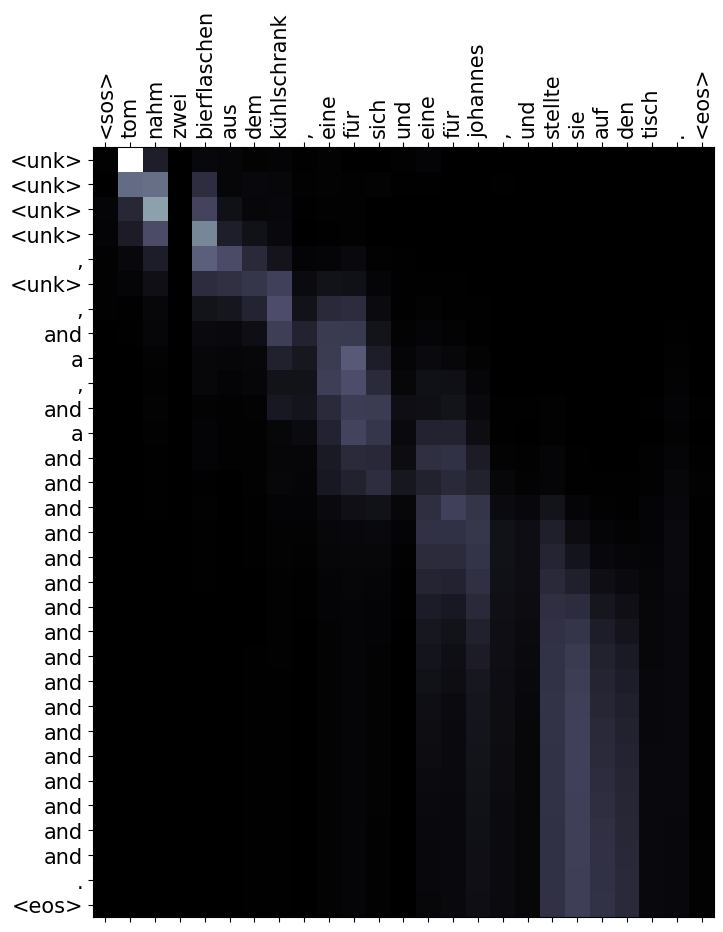

In [170]:
for _, row in stress_dataframe_sorted_wc.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

In [171]:
stress_dataframe_sorted_unique = stress_dataframe.sort_values(by='unique_words', ascending=False)
stress_dataframe_sorted_unique.head()

,translations,sent_tokens,en,word_count,unique_words,attentions,complexities
218945,"[<sos>, this, long, -, haired, <unk>, with, th...","[<sos>, wie, lange, kannst, du, mit, geschloss...",How long can you stand on one leg with your ey...,17,17,"[[[tensor(0.0025), tensor(0.9865), tensor(0.00...",1
228687,"[<sos>, a, <unk>, <unk>, is, a, group, of, peo...","[<sos>, ein, komitee, ist, eine, gruppe, von, ...",A committee is a group of people who individua...,22,16,"[[[tensor(0.0064), tensor(0.1354), tensor(0.41...",2
151104,"[<sos>, a, bride, is, looking, at, the, camera...","[<sos>, hören, sie, auf, zu, reden, und, gehen...",Stop talking and get back to work.,16,15,"[[[tensor(0.0153), tensor(0.7288), tensor(0.18...",1
225752,"[<sos>, i, -, aged, children, approximately, o...","[<sos>, ich, bringe, kindern, nicht, gern, das...",I don't enjoy teaching children to swim when t...,15,15,"[[[tensor(0.0021), tensor(0.9395), tensor(0.03...",1
177029,"[<sos>, lebron, you, <unk>, what, appears, to,...","[<sos>, erzählen, sie, mir, nicht, ,, wie, ich...",Don't tell me how to raise my children.,16,15,"[[[tensor(0.0055), tensor(0.6530), tensor(0.08...",1


DE: <sos> wie lange kannst du mit geschlossenen augen auf einem bein stehen ? <eos>
EN: <sos> How long can you stand on one leg with your eyes closed? <eos>
TR: <sos> this long - haired <unk> with their eyes closed on a a stand , one of them . <eos>


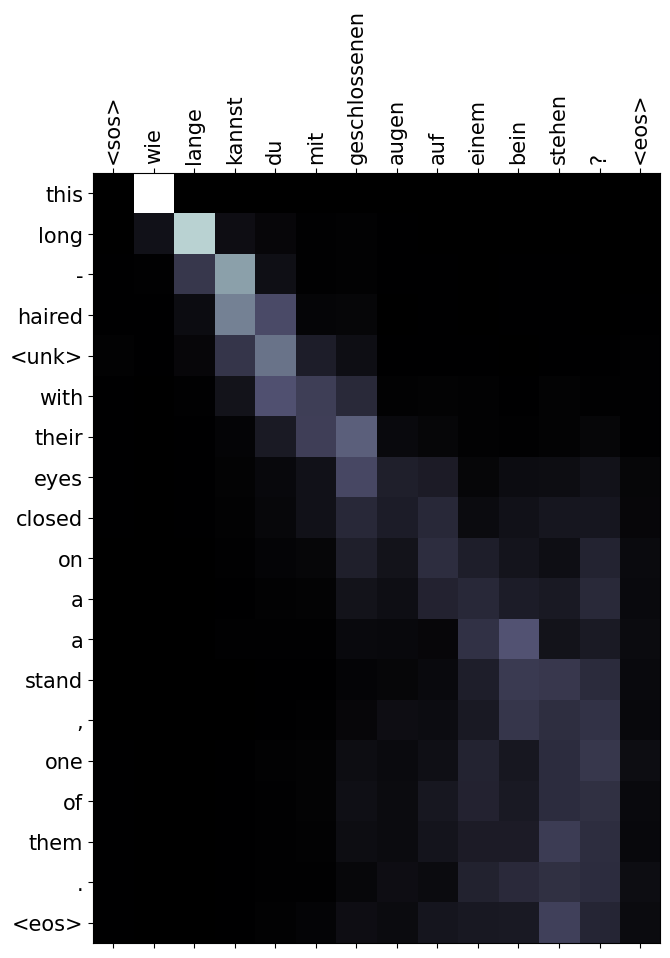

DE: <sos> ein komitee ist eine gruppe von menschen , die als einzelne nichts machen können , die aber als gruppe eine sitzung abhalten und zu der entscheidung gelangen können , dass man nichts machen kann . <eos>
EN: <sos> A committee is a group of people who individually can do nothing, but who, as a group, can meet and decide that nothing can be done. <eos>
TR: <sos> a <unk> <unk> is a group of people , as he is like the <unk> , as they are ready to the the the . <eos>


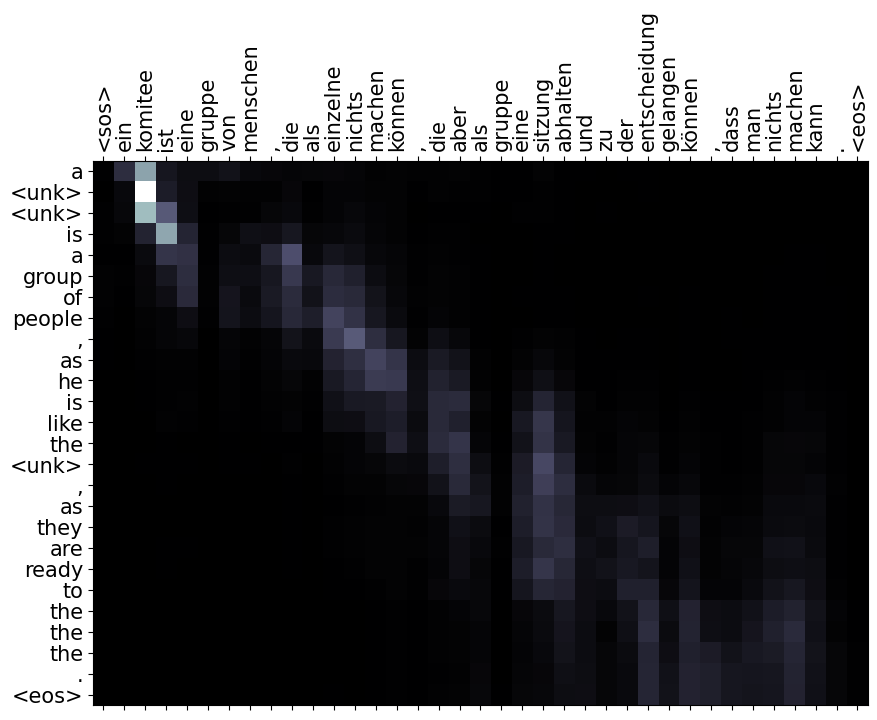

DE: <sos> hören sie auf zu reden und gehen sie zurück an die arbeit ! <eos>
EN: <sos> Stop talking and get back to work. <eos>
TR: <sos> a bride is looking at the camera , they are ready to the new york . <eos>


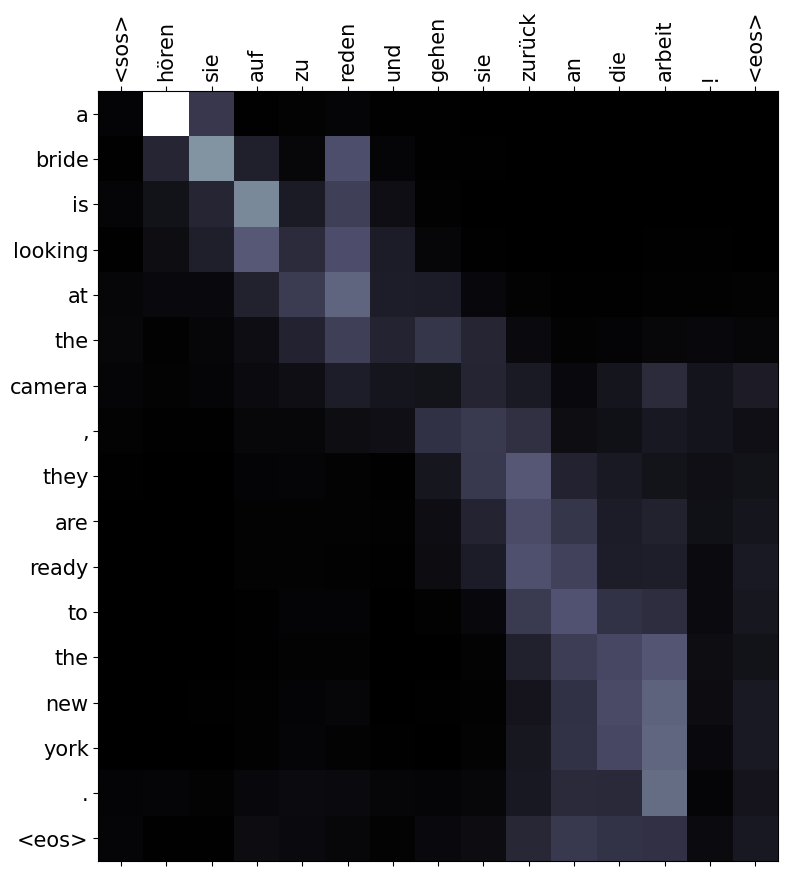

DE: <sos> ich bringe kindern nicht gern das schwimmen bei , wenn die eltern in der nähe sind . <eos>
EN: <sos> I don't enjoy teaching children to swim when their parents are around. <eos>
TR: <sos> i - aged children approximately out of the swimming pool , they are nearby . <eos>


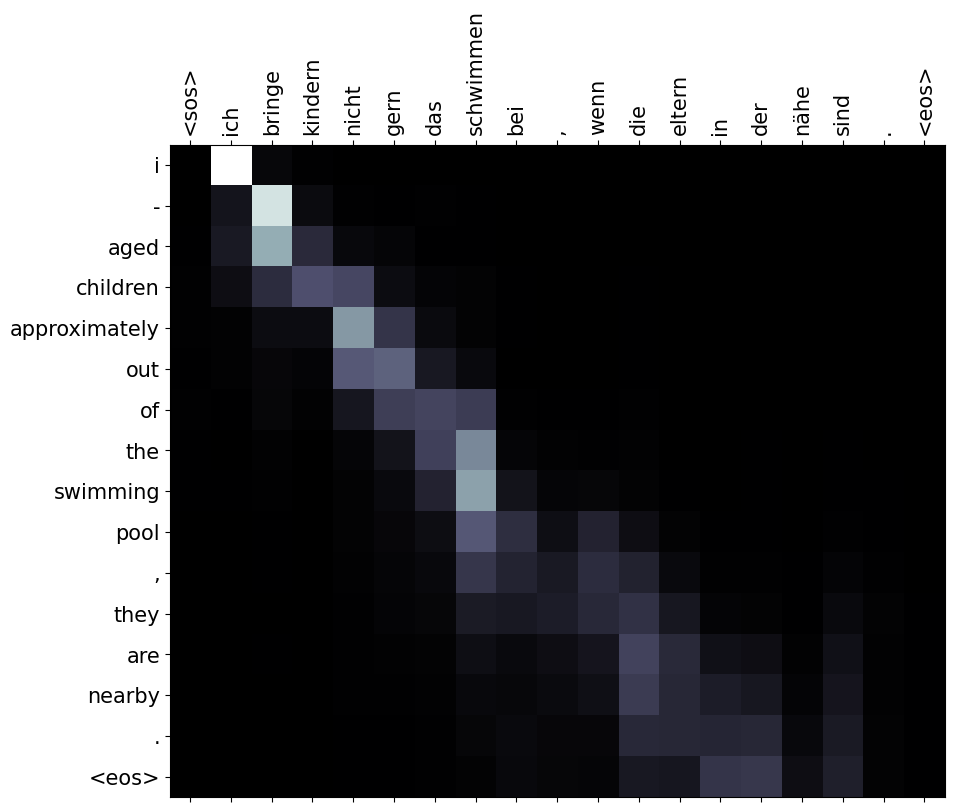

DE: <sos> erzählen sie mir nicht , wie ich meine kinder zu erziehen habe ! <eos>
EN: <sos> Don't tell me how to raise my children. <eos>
TR: <sos> lebron you <unk> what appears to be so so young children who is about to your ! <eos>


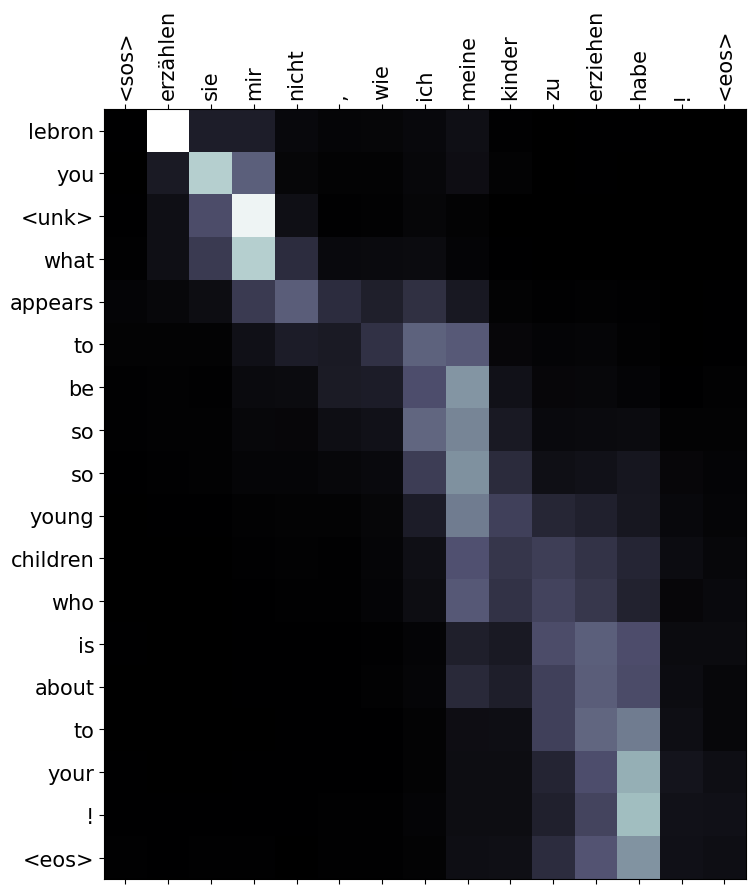

In [172]:
for _, row in stress_dataframe_sorted_unique.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

In [173]:
stress_dataframe_sorted_unique_complexities = stress_dataframe.groupby(by='complexities')
# [stress_dataframe_sorted_unique_complexities.get_group(i) for i in np.arange(1, 5)]
top_rated_of_complexities = [stress_dataframe_sorted_unique_complexities.get_group(i).sort_values(by=['word_count', 'unique_words'], 
                                                                                                  ascending=[False, False]).head(1) for i in np.arange(1, 5)]

Complexity: 1
DE: <sos> tom wälzte sich um 6.30 uhr aus dem bett , schlurfte in die küche und steckte zwei scheiben brot in den toaster . <eos>
EN: <sos> Tom rolled out of bed at 6:30, shuffled into the kitchen and put two slices of bread into the toaster. <eos>
TR: <sos> <unk> <unk> <unk> to be <unk> , the children , they are in the kitchen , two asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian asian


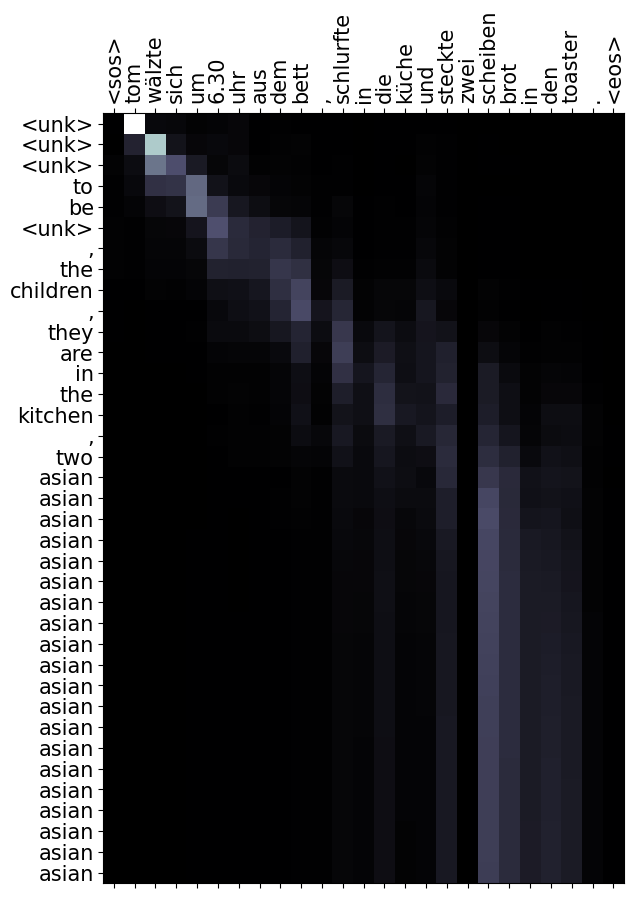

Complexity: 2
DE: <sos> viele gepiercte jugendliche bleiben mit dem partner ein leben lang zusammen – besonders wenn sich der nasenring des einen in der zahnspange des anderen verfangen hat ! <eos>
EN: <sos> Many young people with piercings stay together their whole lives, especially if one gets their nose ring stuck in the other's braces. <eos>
TR: <sos> many <unk> of young boys are <unk> to <unk> , one a , , one is holding a <unk> , one of the other , one is the other . <eos>


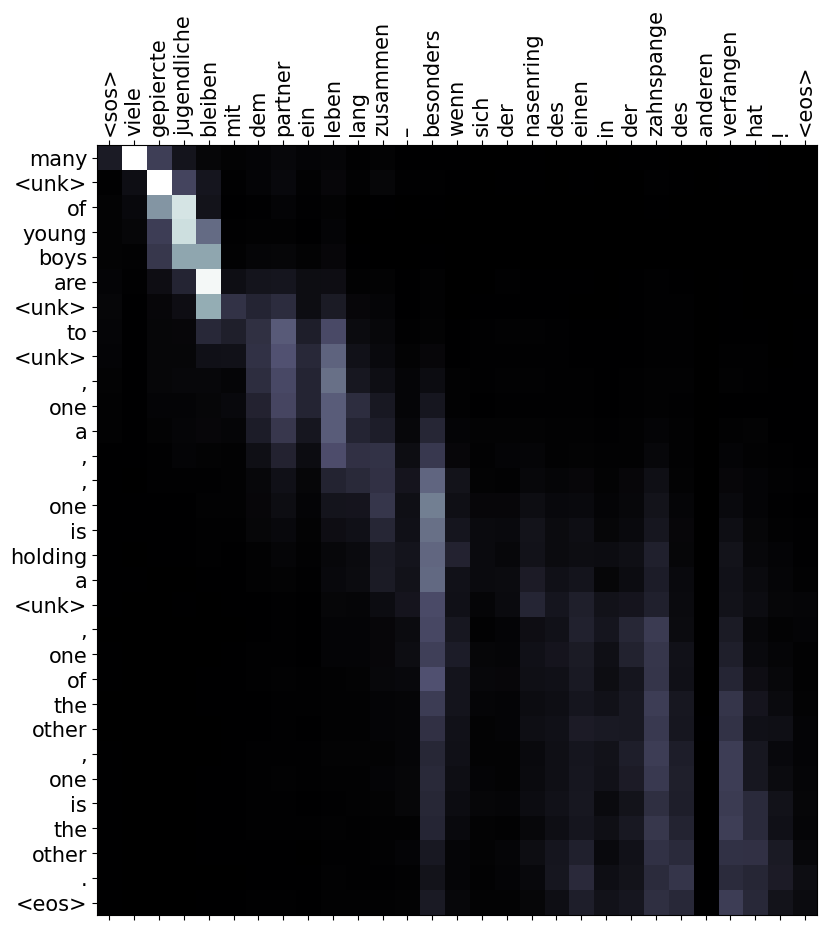

Complexity: 3
DE: <sos> wenn einem von jemandem , der nicht weiß , woher man kommt , gesagt wird , man klinge wie ein muttersprachler , dann heißt das , dass dem an der art , wie man redet , irgendwas aufgefallen sein muss , woran er erkannt hat , dass man eben keiner ist . anders ausgedrückt klingt man eher nicht wie ein muttersprachler . <eos>
EN: <sos> If someone who doesn't know your background says that you sound like a native speaker, it means they probably noticed something about your speaking that made them realize you weren't a native speaker. In other words, you don't really sound like a native speaker. <eos>
TR: <sos> a a game of what appears to be <unk> to so my <unk> so so my <unk> to see the <unk> . <eos>


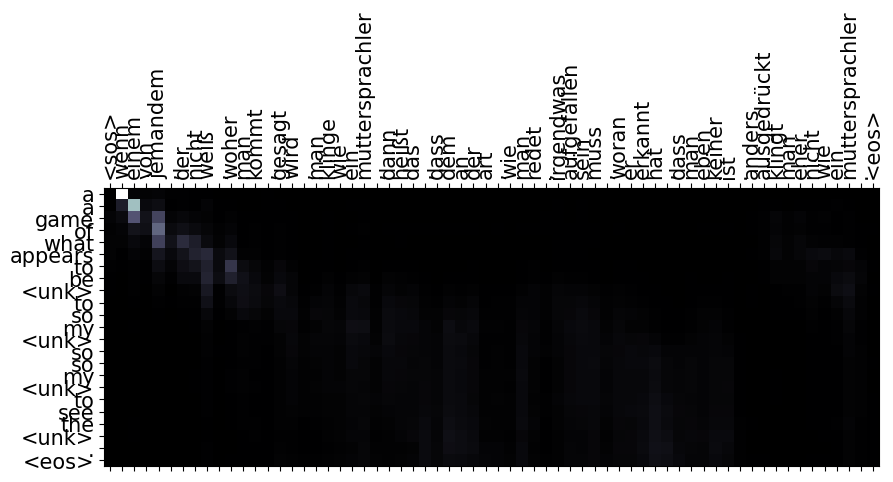

Complexity: 4
DE: <sos> ohne zweifel findet sich auf dieser welt zu jedem mann genau die richtige ehefrau und umgekehrt ; wenn man jedoch in betracht zieht , dass ein mensch nur gelegenheit hat , mit ein paar hundert anderen bekannt zu sein , von denen ihm nur ein dutzend oder weniger nahesteht , darunter höchstens ein oder zwei freunde , dann erahnt man eingedenk der millionen einwohner dieser welt   leicht , dass seit erschaffung ebenderselben wohl noch nie der richtige mann der richtigen frau begegnet ist . <eos>
EN: <sos> Doubtless there exists in this world precisely the right woman for any given man to marry and vice versa; but when you consider that a human being has the opportunity of being acquainted with only a few hundred people, and out of the few hundred that there are but a dozen or less whom he knows intimately, and out of the dozen, one or two friends at most, it will easily be seen, when we remember the number of millions who inhabit this world, that probably, since th

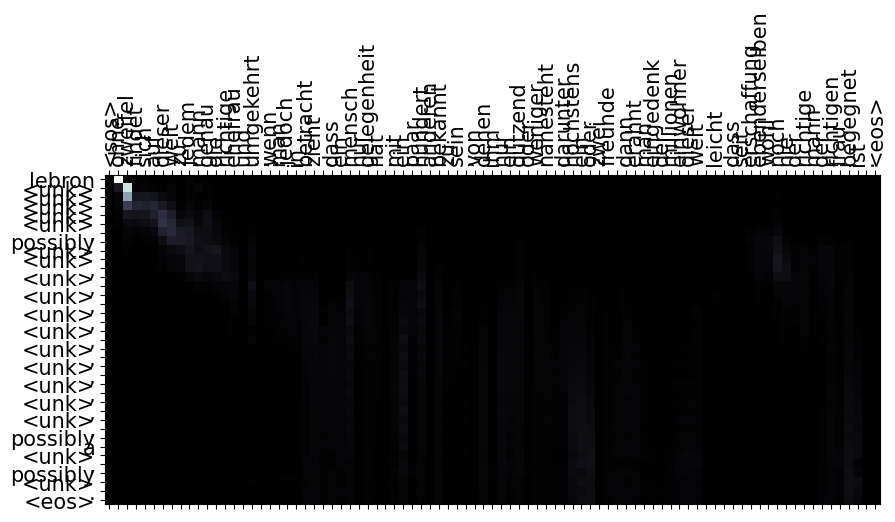

In [174]:
for top_complex in top_rated_of_complexities:
    top_row = top_complex.iloc[0]
    print('Complexity:', top_row['complexities'])
    print('DE:', ' '.join(top_row['sent_tokens']))
    print('EN: <sos>', top_row['en'], '<eos>')
    print('TR:', ' '.join(top_row['translations']))
    plot_attention(top_row['sent_tokens'], top_row['translations'], top_row['attentions'])

DE: <sos> ich bringe kindern nicht gern das schwimmen bei , wenn die eltern in der nähe sind . <eos>
EN: <sos> I don't enjoy teaching children to swim when their parents are around. <eos>
TR: <sos> i - aged children approximately out of the swimming pool , they are nearby . <eos>


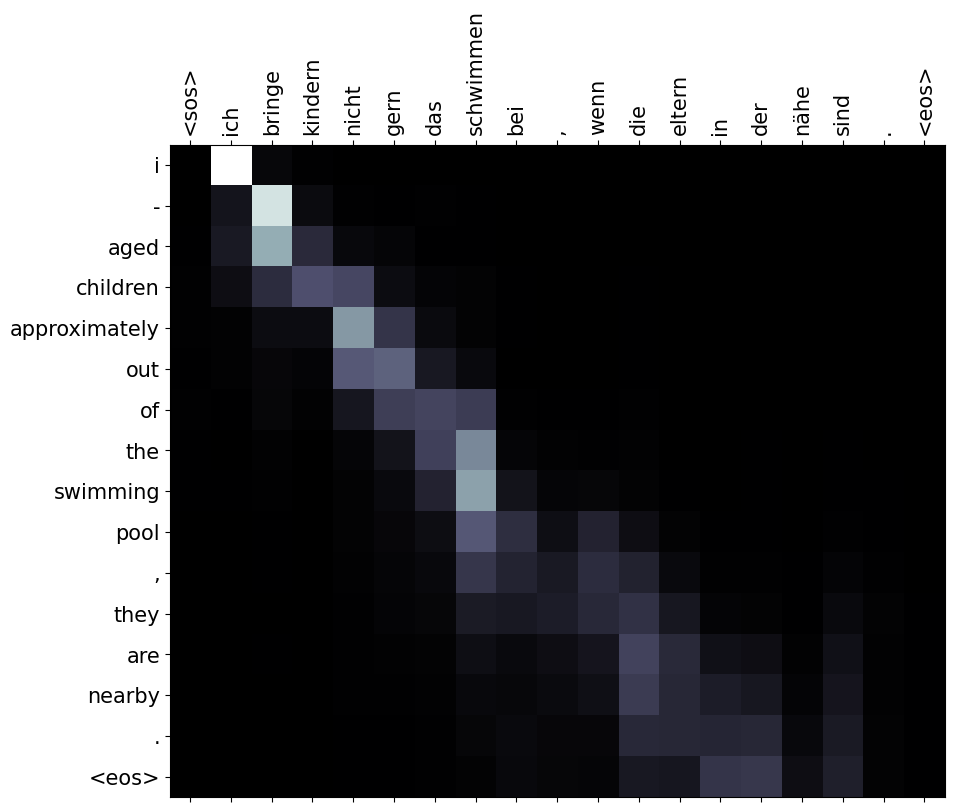

DE: <sos> hören sie auf zu reden und gehen sie zurück an die arbeit ! <eos>
EN: <sos> Stop talking and get back to work. <eos>
TR: <sos> a bride is looking at the camera , they are ready to the new york . <eos>


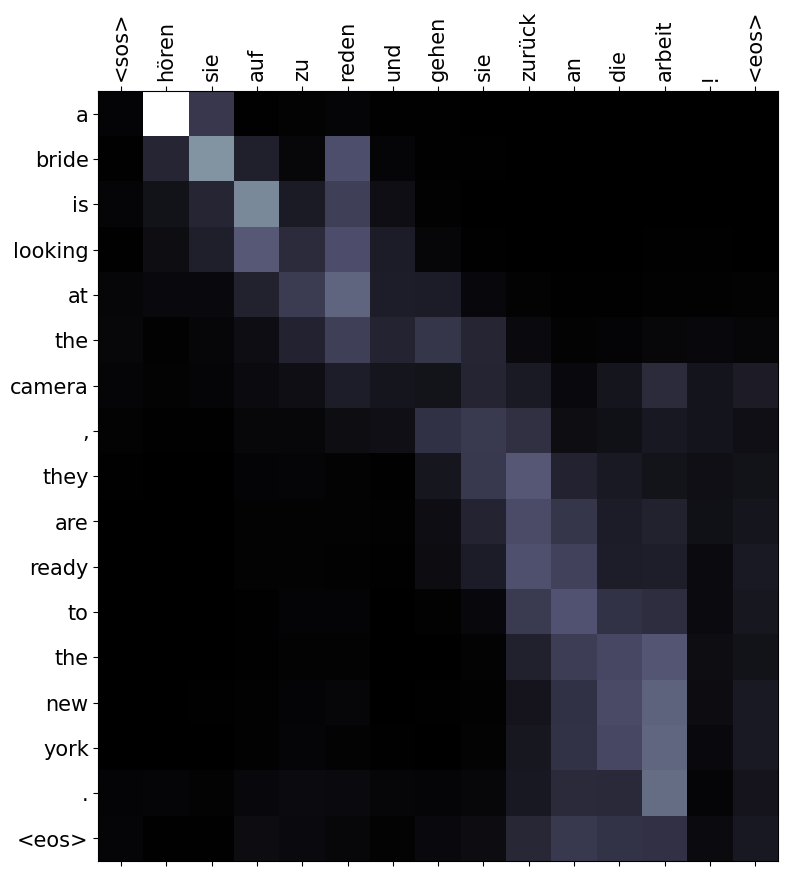

DE: <sos> wir haben noch einen langen weg vor uns . <eos>
EN: <sos> We've still got a long way to go. <eos>
TR: <sos> we have a long long - up to each other in front of them . <eos>


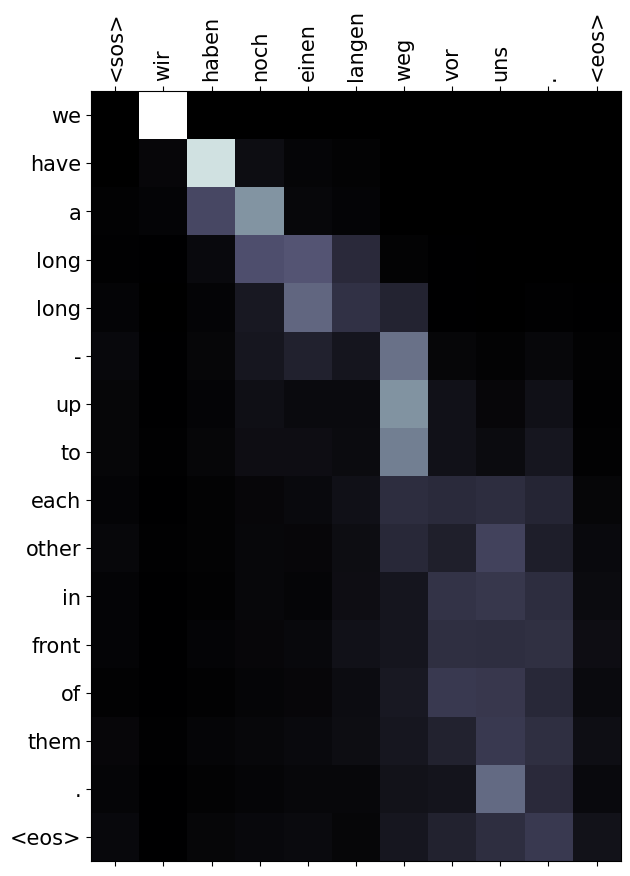

DE: <sos> es ist viel teurer , essen zu gehen , als sich zu hause etwas zu machen . <eos>
EN: <sos> It's much more expensive to eat out than to eat at home. <eos>
TR: <sos> a are many families eating food , while they are preparing to be something . <eos>


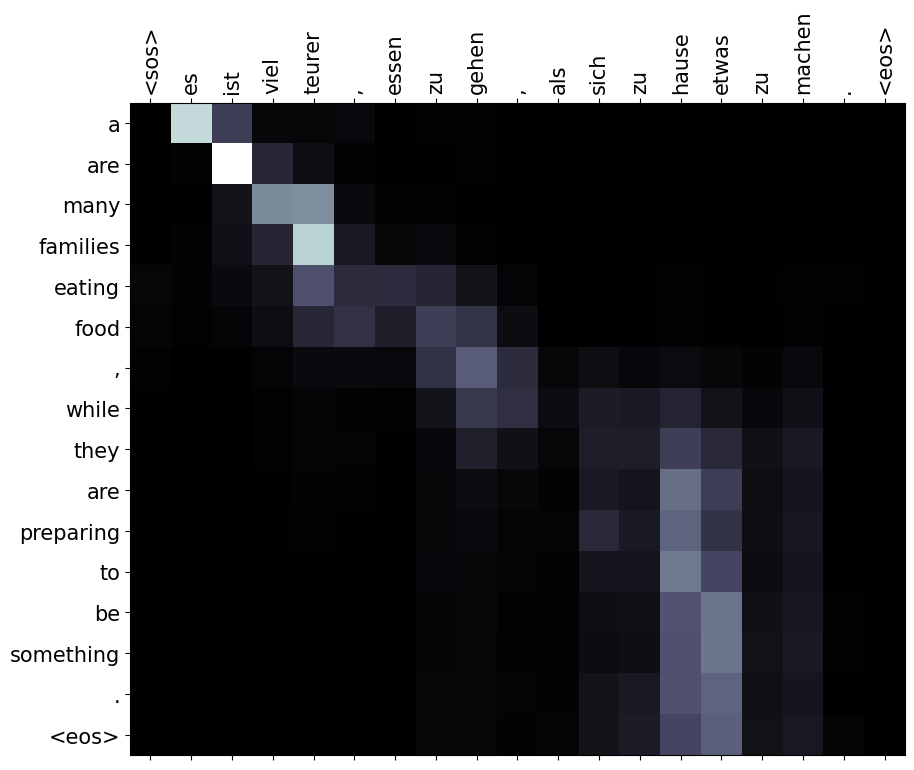

DE: <sos> ich habe drei hunde . einer ist ein männchen und die anderen beiden sind weibchen . <eos>
EN: <sos> I have three dogs. One is male and the other two are female. <eos>
TR: <sos> this is three three dogs are a a toy in the other and two other men . <eos>


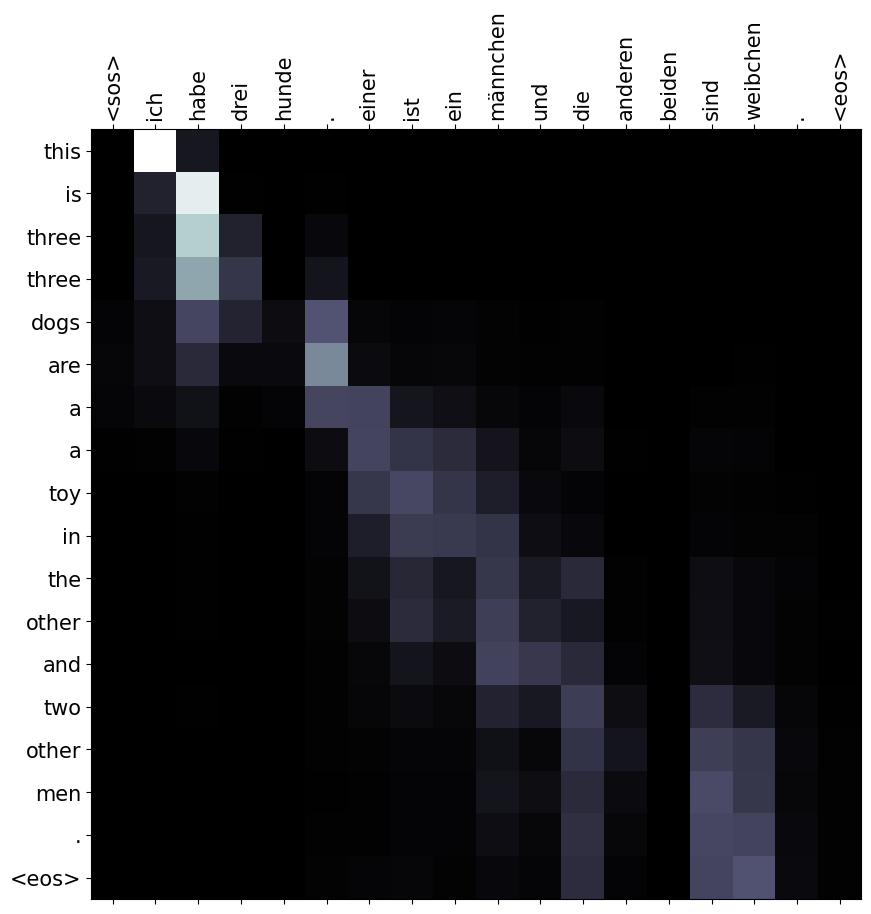

In [201]:
stress_perfects_dataframe = stress_dataset_perfects.make_dataframe()
stress_perfects_dataframe_sorted = stress_perfects_dataframe.sort_values(by='unique_words', ascending=False)
for _, row in stress_perfects_dataframe_sorted.head().iterrows():
    print('DE:', ' '.join(row['sent_tokens']))
    print('EN: <sos>', row['en'], '<eos>')
    print('TR:', ' '.join(row['translations']))
    plot_attention(row['sent_tokens'], row['translations'], row['attentions'])

In [207]:
stress_perfects_dataframe_sorted.head()

,translations,sent_tokens,en,word_count,unique_words,attentions,complexities
30155,"[<sos>, i, -, aged, children, approximately, o...","[<sos>, ich, bringe, kindern, nicht, gern, das...",I don't enjoy teaching children to swim when t...,15,15,"[[[tensor(0.0021), tensor(0.9395), tensor(0.03...",1
23874,"[<sos>, a, bride, is, looking, at, the, camera...","[<sos>, hören, sie, auf, zu, reden, und, gehen...",Stop talking and get back to work.,16,15,"[[[tensor(0.0153), tensor(0.7288), tensor(0.18...",1
23357,"[<sos>, we, have, a, long, long, -, up, to, ea...","[<sos>, wir, haben, noch, einen, langen, weg, ...",We've still got a long way to go.,15,14,"[[[tensor(0.0012), tensor(0.9922), tensor(0.00...",1
29931,"[<sos>, a, are, many, families, eating, food, ...","[<sos>, es, ist, viel, teurer, ,, essen, zu, g...",It's much more expensive to eat out than to ea...,15,14,"[[[tensor(0.0063), tensor(0.6260), tensor(0.20...",1
30033,"[<sos>, this, is, three, three, dogs, are, a, ...","[<sos>, ich, habe, drei, hunde, ., einer, ist,...",I have three dogs. One is male and the other t...,17,14,"[[[tensor(0.0037), tensor(0.8883), tensor(0.09...",1


In [204]:
stress_perfects_dataframe_sorted['complexities'].value_counts()

complexities
1    30201
2        2
Name: count, dtype: int64

## Custom Sentences

In [175]:
# sentences = ['ich möchte das kaufen', 'alles ist seinen Preis wert', 'wie viel kostet das', 'ich mochte ein bier ']
german_sents = ['Sie sahen ihn schon von weitem auf sich zukommen, denn er fiel auf.',
                'Er hatte ein ganz altes Gesicht, aber wie er ging, daran sah man, dass er erst zwanzig war.',
                'Er setzte sich mit seinem alten Gesicht zu ihnen auf die Bank. Und dann zeigte er ihnen, was er in der Hand trug.',
                '“Das war unsere Küchenuhr“, sagte er und sah sie alle der Reihe nach an, die auf der Bank in der Sonne saßen. “Ja, ich habe sie noch gefunden. Sie ist übriggeblieben.”',
                'Er hielt eine runde tellerweiße Küchenuhr vor sich hin und tupfte mit dem Finger die blaugemalten Zahlen ab.',
                '“Sie hat weiter keinen Wert,” meinte er entschuldigend, “das weiß ich auch. Und sie ist auch nicht so besonders schön. Sie ist nur wie ein Teller, so mit weißem Lack. Aber die blauen Zahlen sehen doch ganz hübsch aus, finde ich. Die Zeiger sind natürlich nur aus Blech. Und nun gehen sie auch nicht mehr. Nein. Innerlich ist sie kaputt, das steht fest. Aber sie sieht noch aus wie immer. Auch wenn sie jetzt nicht mehr geht.”',
                ''
               ] # https://learnoutlive.com/die-kuchenuhr-wolfgang-borchert/
english_sents = ['They saw him from far off, coming towards him, because he stuck out.',
                 'He had a very old face, but as he approached, it was noticeable that he was actually only about twenty.',
                 'He sat down with his old face beside them on the bench. And then he showed them what was in his hand.',
                 '“It was our kitchen clock”, he said, and looked at them all, one after the other, who sat on the bench in the sun. “Yes, I found it. It’s still here.”',
                 'He held up a round, china-white kitchen clock, and dabbed the blue painted numbers with his fingers.',
                 '“It’s worthless now”, he said apologetically, “I know that too. And it’s also not especially appealing.  It is just like a plate, with its plain white lacquer. But the blue numbers still look very pretty, I think. The hands are naturally only rough bits of tin. And now they don’t work any more, besides. No. Inside it’s broken, that’s for sure. But it still looks like it always did. Even if it doesn’t work any more.”',
                 ''
                ] # https://therhinocolumn.wordpress.com/2014/05/01/the-kitchen-clock/



In [176]:
for i, (de_sent, en_sent) in enumerate(zip(german_sents, english_sents)):
    translation, sentence_tokens, attention = translate_sentence(
        de_sent,
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )
    print('='*20, f'Translation {i+1}')
    print('DE:', de_sent)
    print('EN:', en_sent)
    print('TR:', ' '.join(translation))

==================== Translation 1
DE: Sie sahen ihn schon von weitem auf sich zukommen, denn er fiel auf.
EN: They saw him from far off, coming towards him, because he stuck out.
TR: <sos> they are <unk> <unk> <unk> <unk> <unk> <unk> <unk> . <eos>
==================== Translation 2
DE: Er hatte ein ganz altes Gesicht, aber wie er ging, daran sah man, dass er erst zwanzig war.
EN: He had a very old face, but as he approached, it was noticeable that he was actually only about twenty.
TR: <sos> this is a piece of paper , know know know <unk> <unk> <unk> . <eos>
==================== Translation 3
DE: Er setzte sich mit seinem alten Gesicht zu ihnen auf die Bank. Und dann zeigte er ihnen, was er in der Hand trug.
EN: He sat down with his old face beside them on the bench. And then he showed them what was in his hand.
TR: <sos> the <unk> <unk> with his his his his his on the the and he is his teeth . <eos>
==================== Translation 4
DE: “Das war unsere Küchenuhr“, sagte er und sah s